# Results for Paper "Evaluating the Educational Impact of a Large Language Model (LLM)Based Virtual Assistant in Video-Based Learning"

---

In [257]:
import os, sys
import polars as pl
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable, Independence

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact.educational_impact_analysis import (
    group_stats,
    compute_correlations,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison,
    plot_quant_comparison_faceted,
    plot_quant_scatter,
    plot_quant_pie,
    plot_cat_comparison_faceted,
    plot_cat_comparison_heatmap,
    plot_cat_comparison_faceted_heatmap
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [258]:
forms_interactions_df['group'].value_counts()

group,count
str,u32
"""experimental""",94
"""control""",97


In [259]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
null,100
"""Low""",25
"""Not Used""",29
"""High""",37


In [260]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [261]:
forms_interactions_df['group'].value_counts().filter(pl.col('group') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [262]:
forms_interactions_df.filter(
    pl.col('group') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,improvement_retention_hake_gain,improvement_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,score_tc_pre,…,chat_freq_use_v2,chat_freq_use,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat_v2,WSDI_cat,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,group_segmented_v1,group_segmented_v2,group_segmented_quality,group_segmented_freq_quality,group_segmented_v5,group_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,str,bool,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [263]:
forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,improvement_retention_hake_gain,improvement_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,score_tc_pre,…,chat_freq_use_v2,chat_freq_use,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat_v2,WSDI_cat,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,group_segmented_v1,group_segmented_v2,group_segmented_quality,group_segmented_freq_quality,group_segmented_v5,group_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,str,bool,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,-1.0,"""Low""","""Low""","""Low""",-0.1,0.0,-0.2,"""Low""","""Low""","""Low""",0.41,"""Medium""",0.25,"""Worsen""",false,false,"""Not Improve""","""Worsen""","""Improve""","""Worsenmiento-Alto""","""Worsenmiento-Alto""","""Excellent""","""Very Good-Excellent""","""Very Good-Excellent""","""Very Good-Excellent""","""Very Good""","""Very Good-Excellent""","""Very Good-Excellent""","""Fail-Pass-Good""","""11/03/2026 9:48:45""","""11/03/2026 10:27:34""",0.9,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,38.816667,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.0,"""Low""","""Low""","""Low""",0.0,-0.2,0.0,"""Low""","""Low""","""Low""",0.562,"""High""",0.18,"""Not Improve""",false,false,"""Worsen""","""Not Improve""","""Improve""","""Not Improve""","""Not Improve""","""Very Good""","""Very Good-Excellent""","""Very Good-Excellent""","""Fail-Pass-Good""","""Very Good""","""Very Good-Excellent""","""Fail-Pass-Good""","""Fail-Pass-Good""","""11/03/2026 9:50:39""","""11/03/2026 10:30:02""",0.7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.383333,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Low""","""Low""","""Low""",-0.5,-0.6,-0.4,"""Low""","""Low""","""Low""",0.111,"""Medium""",0.04,"""Worsen""",false,false,"""Worsen""","""Worsen""","""Improve""","""Worsenmiento-Alto""","""Worsenmiento-Alto""","""Good""","""Fail-Pass-Good""","""Very Good-Excellent""","""Fail-Pass-Good""","""Fail""","""Fail-Pass-Good""","""Fail-Pass-Good""","""Fail-Pass-Good""","""1

---

## Descripción general

In [264]:
forms_interactions_df.describe()

statistic,id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,improvement_retention_hake_gain,improvement_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,…,chat_freq_use_v2,chat_freq_use,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat_v2,WSDI_cat,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,group_segmented_v1,group_segmented_v2,group_segmented_quality,group_segmented_freq_quality,group_segmented_v5,group_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,f64,str,str,f64,f64,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,"""191""",191.0,"""191""",191.0,191.0,"""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""",…,"""91""","""91""",62.0,62.0,62.0,62.0,62.0,"""91""","""91""","""91""",62.0,51.0,51.0,"""91""","""91""","""91""","""91""","""91""","""91""","""188""","""188""","""188""","""188""","""188""","""188""",191.0,"""163""","""163""","""163""",163.0,163.0,163.0,"""163""","""163""",163.0,163.0,163.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,"""0""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",…,"""100""","""100""",129.0,129.0,129.0,129.0,129.0,"""100""","""100""","""100""",129.0,140.0,140.0,"""100""","""100""","""100""","""100""","""100""","""100""","""3""","""3""","""3""","""3""","""3""","""3""",0.0,"""28""","""28""","""28""",28.0,28.0,28.0,"""28""","""28""",28.0,28.0,28.0
"""mean""",null,null,null,0.312508,0.209445,0.168932,null,null,null,0.162304,0.125654,0.147644,null,null,null,0.111822,null,0.095707,null,0.717277,0.717277,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,1.737468,1.306452,0.451613,1.080645,0.854839,null,null,null,0.367665,2.176471,0.176471,null,null,null,null,null,null,null,null,null,null,null,null,32.646248,null,null,null,40.399811,-3.678199,2.8075e9,null,null,26842.638037,59652.404908,21326.760736
"""std""",null,null,null,0.632694,0.839672,0.493354,null,null,null,0.21062,0.271684,0.246624,null,null,null,0.826736,null,0.192185,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,0.70161,1.409438,1.096603,1.07579,1.099132,null,null,null,0.351898,1.260252,0.47774,null,null,null,null,null,null,null,null,null,null,null,null,7.847541,null,null,null,0.057662,0.03281

---

## Análisis de resultados


### Definición de variables

In [265]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64, pl.UInt32]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

context_cols = ['school', 'group']

schools_cols = [ 
    'nombre',
    'direccion',
    'curso',
    'lat',
    'lon',
    'seccion_censal',
    'municipio',
    'provincia',
    'mediana_renta_uc_eur',
    'renta_media_hogar_eur',
    'renta_media_persona_eur'
]

time_cols = [col for col in forms_interactions_df.columns if 'temp' in col or 'time' in col]

group_segmented_cols = [ 
    'group_segmented_v1',
    'group_segmented_v2',
    'group_segmented_freq_quality',
    'group_segmented_quality',
    'group_segmented_v5',
    'group_segmented_v6'
]

forms_cols = [col for col in forms_interactions_df.columns if 'score' in col or 'mejora' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + schools_cols + time_cols + group_segmented_cols + ['id']]
chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

### Variables de contexto

### Métricas de Rendimiento Forms

#### TC-Hake

In [266]:
hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' not in col and "tc" in col]
units_hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' in col and "tc" in col]

hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' not in col and 'mejora' not in col and "tc" in col]
units_hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' in col and 'mejora' not in col and "tc" in col]

#### TC-Pre-Post

In [267]:
tc_pre_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col]
tc_pre_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col and 'trad' not in col]

tc_post_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col]
tc_post_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col and  'trad' not in col] 

#### TC-Pre-Post Mejora

#### TA-Pre-Post

In [268]:
ta_quant_cols = [col for col in forms_quant_cols if 'ta_' in col]
ta_cat_cols = [col for col in forms_cat_cols if 'ta_' in col]

#### TCC-Post

In [269]:
tcc_quant_cols = [col for col in forms_quant_cols if 'tcc_' in col]
tcc_cat_cols = [col for col in forms_cat_cols if 'tcc_' in col]

### Métricas Interacciones Herramienta

### Análisis Cruzado 

#### Filtrado de participantes problematicos

In [270]:
q25 = forms_interactions_df['score_tc_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('score_tc_hake_gain') < outliers_lower_bound
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""RamiroMaeztu-86g""","""experimental""",0.8,0.5,-0.3,-1.5
"""RamiroMaeztu-4bc""","""experimental""",0.9,0.6,-0.3,-3.0
"""JesusMaria-ub4""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-yxb""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25
"""Laguna-chk""","""experimental""",0.9,0.6,-0.3,-3.0


In [271]:
q25 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('score_tc_units_hake_gain') < outliers_lower_bound
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25


In [272]:
forms_interactions_df.filter(
    pl.col('score_tc_pre') == 1
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""JoseGarciaNieto-lp9""","""control""",1.0,0.9,0.0,0.0
"""JesusMaria-86o""","""control""",1.0,1.0,0.0,0.0
"""Laguna-o61""","""experimental""",1.0,0.5,0.0,0.0
"""Laguna-yno""","""experimental""",1.0,0.8,0.0,0.0
"""Laguna-9wq""","""experimental""",1.0,0.9,0.0,0.0


In [273]:
forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain', 'chat_freq_use']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain,chat_freq_use
str,str,f64,f64,f64,f64,str
"""JesusMaria-nre""","""experimental""",0.9,0.8,-0.1,-1.0,null
"""JesusMaria-3ci""","""experimental""",0.7,0.7,0.0,0.0,null
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25,null


In [274]:
problematic_ids = forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

q25 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr
problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('score_tc_units_hake_gain') < outliers_lower_bound
)['id'].to_list()

problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('score_tc_pre') == 1
)['id'].to_list()

problematic_ids = list(set(problematic_ids))

forms_interactions_df = forms_interactions_df.filter(~pl.col('id').is_in(problematic_ids))

In [275]:
#Define paths

plots_path = os.path.join(project_path, 'plots')
os.makedirs(plots_path, exist_ok=True)

## Baseline Results

In [276]:
baseline_path = os.path.join(plots_path, '5_1')
os.makedirs(baseline_path, exist_ok=True)

### TC Pre

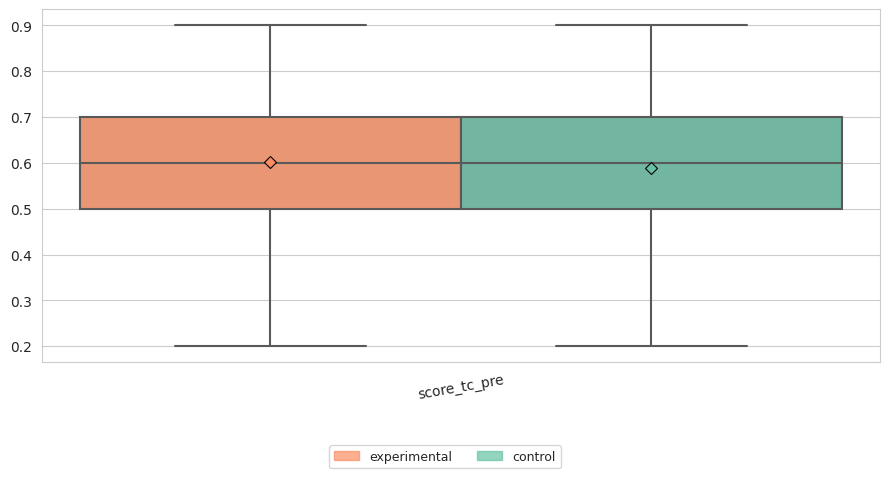

In [277]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(baseline_path, 'tc_pre.pdf')
)

In [278]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME = 'score_tc_pre'
d = df.dropna(subset=[OUTCOME, 'group', 'school']).copy()

# 1 = experimental: beta > 0 y g > 0 significan lo mismo
d['group_binary'] = (d['group'] == 'experimental').astype(int)

e = d.loc[d['group_binary'] == 1, OUTCOME]   # experimental
c = d.loc[d['group_binary'] == 0, OUTCOME]   # control
n1, n2 = len(e), len(c)

# ================== DESCRIPTIVOS ==================
desc = (d.groupby('group')[OUTCOME]
          .agg(n='size', mean='mean', sd='std', median='median',
               q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75),
               min='min', max='max')
          .round(4))
desc['iqr'] = (desc['q3'] - desc['q1']).round(4)
print("--- Descriptivos por condición ---")
print(desc, "\n")

print(f"diferencia de medias   = {e.mean() - c.mean():+.4f}")
print(f"diferencia de medianas = {e.median() - c.median():+.4f}")
print(f"IQR: exp [{e.quantile(.25):.2f}, {e.quantile(.75):.2f}] "
      f"vs ctrl [{c.quantile(.25):.2f}, {c.quantile(.75):.2f}]\n")

print("--- Forma ---")
for lbl, s in [('experimental', e), ('control', c)]:
    print(f"{lbl:<13} skew = {s.skew():+.3f}, kurtosis = {s.kurt():+.3f}, "
          f"valores únicos = {s.nunique()}")

qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("\n--- Cuantiles comparados ---")
print(pd.DataFrame({'exp': e.quantile(qs).round(3),
                    'ctrl': c.quantile(qs).round(3)}), "\n")

# ---- Contexto del ICC: variación entre centros ----
school_means = d.groupby('school')[OUTCOME].mean()
print("--- Media del pre por centro y condición ---")
print(d.pivot_table(index='school', columns='group',
                    values=OUTCOME, aggfunc=['size', 'mean']).round(4), "\n")
print("media por centro:", school_means.round(4).to_dict())
print(f"rango entre centros = {school_means.max() - school_means.min():.4f}\n")

# ================== MODELO M1 ==================
res = smf.mixedlm(f"{OUTCOME} ~ group_binary", data=d,
                  groups=d['school'], re_formula="1").fit(reml=True)

beta, se = res.params['group_binary'], res.bse['group_binary']
p_val = res.pvalues['group_binary']              # Wald z, sin corrección de gl
ci_lo, ci_hi = res.conf_int().loc['group_binary']

var_school, var_resid = float(res.cov_re.iloc[0, 0]), float(res.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

# ---- Hedges' g (descriptivo, no ajustado por clustering) ----
s_pooled = np.sqrt(((n1 - 1) * e.std(ddof=1)**2 + (n2 - 1) * c.std(ddof=1)**2)
                   / (n1 + n2 - 2))
g = ((e.mean() - c.mean()) / s_pooled) * (1 - 3 / (4 * (n1 + n2) - 9))
se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
z = stats.norm.ppf(0.975)

# ---- Salida ----
print("--- Modelo M1 ---")
print(f"n = {n1 + n2} (exp {n1}, ctrl {n2}) | schools = {d['school'].nunique()} "
      f"| converged = {res.converged}")
print(f"beta = {beta:.4f} (SE {se:.4f}, p {p_val:.4f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Hedges' g = {g:.4f} (95% CI [{g - z*se_g:.4f}, {g + z*se_g:.4f}])")

--- Descriptivos por condición ---
               n    mean      sd  median   q1   q3  min  max  iqr
group                                                            
control       95  0.5884  0.1809     0.6  0.5  0.7  0.2  0.9  0.2
experimental  88  0.6011  0.1636     0.6  0.5  0.7  0.2  0.9  0.2 

diferencia de medias   = +0.0127
diferencia de medianas = +0.0000
IQR: exp [0.50, 0.70] vs ctrl [0.50, 0.70]

--- Forma ---
experimental  skew = -0.421, kurtosis = -0.201, valores únicos = 8
control       skew = -0.352, kurtosis = -0.377, valores únicos = 8

--- Cuantiles comparados ---
       exp  ctrl
0.05  0.30  0.27
0.10  0.37  0.30
0.25  0.50  0.50
0.50  0.60  0.60
0.75  0.70  0.70
0.90  0.80  0.80
0.95  0.80  0.90 

--- Media del pre por centro y condición ---
                   size                 mean             
group           control experimental control experimental
school                                                   
JesusMaria           26           22  0.6538       0.5

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


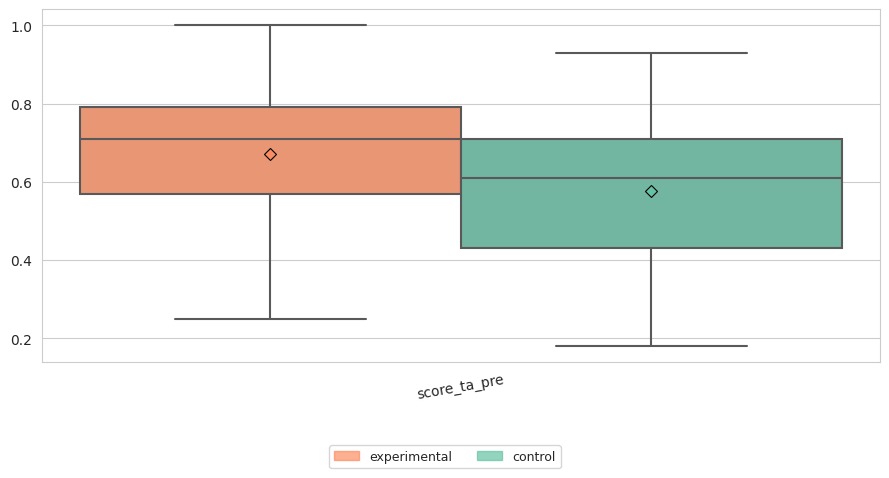

In [279]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_ta_pre"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(baseline_path, 'ta_pre.pdf')
)

In [280]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME = 'score_ta_pre'
d = df.dropna(subset=[OUTCOME, 'group', 'school']).copy()

# 1 = experimental: beta > 0 y g > 0 significan lo mismo
d['group_binary'] = (d['group'] == 'experimental').astype(int)

e = d.loc[d['group_binary'] == 1, OUTCOME]   # experimental
c = d.loc[d['group_binary'] == 0, OUTCOME]   # control
n1, n2 = len(e), len(c)

# ================== DESCRIPTIVOS ==================
desc = (d.groupby('group')[OUTCOME]
          .agg(n='size', mean='mean', sd='std', median='median',
               q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75),
               min='min', max='max')
          .round(4))
desc['iqr'] = (desc['q3'] - desc['q1']).round(4)
print("--- Descriptivos por condición ---")
print(desc, "\n")

print(f"diferencia de medias   = {e.mean() - c.mean():+.4f}")
print(f"diferencia de medianas = {e.median() - c.median():+.4f}")
print(f"IQR: exp [{e.quantile(.25):.3f}, {e.quantile(.75):.3f}] "
      f"vs ctrl [{c.quantile(.25):.3f}, {c.quantile(.75):.3f}]\n")

print("--- Forma ---")
for lbl, s in [('experimental', e), ('control', c)]:
    print(f"{lbl:<13} skew = {s.skew():+.3f}, kurtosis = {s.kurt():+.3f}, "
          f"valores únicos = {s.nunique()}")

qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("\n--- Cuantiles comparados ---")
print(pd.DataFrame({'exp': e.quantile(qs).round(3),
                    'ctrl': c.quantile(qs).round(3)}), "\n")

# ---- Contexto del ICC: variación entre centros ----
school_means = d.groupby('school')[OUTCOME].mean()
print("--- Media por centro y condición ---")
print(d.pivot_table(index='school', columns='group',
                    values=OUTCOME, aggfunc=['size', 'mean']).round(4), "\n")
print("media por centro:", school_means.round(4).to_dict())
print(f"rango entre centros = {school_means.max() - school_means.min():.4f}\n")

# ---- Rango observado de la escala (comprobación del escalado) ----
print(f"rango global observado: [{d[OUTCOME].min():.4f}, {d[OUTCOME].max():.4f}]\n")

# ================== MODELO M1 ==================
res = smf.mixedlm(f"{OUTCOME} ~ group_binary", data=d,
                  groups=d['school'], re_formula="1").fit(reml=True)

beta, se = res.params['group_binary'], res.bse['group_binary']
p_val = res.pvalues['group_binary']              # Wald z, sin corrección de gl
ci_lo, ci_hi = res.conf_int().loc['group_binary']

var_school, var_resid = float(res.cov_re.iloc[0, 0]), float(res.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

# ---- Hedges' g (descriptivo, no ajustado por clustering) ----
s_pooled = np.sqrt(((n1 - 1) * e.std(ddof=1)**2 + (n2 - 1) * c.std(ddof=1)**2)
                   / (n1 + n2 - 2))
g = ((e.mean() - c.mean()) / s_pooled) * (1 - 3 / (4 * (n1 + n2) - 9))
se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
z = stats.norm.ppf(0.975)

# ---- Salida ----
print("--- Modelo M1 ---")
print(f"OUTCOME = {OUTCOME}")
print(f"n = {n1 + n2} (exp {n1}, ctrl {n2}) | schools = {d['school'].nunique()} "
      f"| converged = {res.converged}")
print(f"beta = {beta:.4f} (SE {se:.4f}, p {p_val:.4f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Hedges' g = {g:.4f} (95% CI [{g - z*se_g:.4f}, {g + z*se_g:.4f}])")

--- Descriptivos por condición ---
               n    mean      sd  median    q1    q3   min   max   iqr
group                                                                 
control       95  0.5755  0.1877    0.61  0.43  0.71  0.18  0.93  0.28
experimental  88  0.6703  0.1632    0.71  0.57  0.79  0.25  1.00  0.22 

diferencia de medias   = +0.0949
diferencia de medianas = +0.1000
IQR: exp [0.570, 0.790] vs ctrl [0.430, 0.710]

--- Forma ---
experimental  skew = -0.605, kurtosis = +0.005, valores únicos = 20
control       skew = -0.063, kurtosis = -0.784, valores únicos = 22

--- Cuantiles comparados ---
       exp   ctrl
0.05  0.32  0.278
0.10  0.46  0.320
0.25  0.57  0.430
0.50  0.71  0.610
0.75  0.79  0.710
0.90  0.86  0.820
0.95  0.89  0.860 

--- Media por centro y condición ---
                   size                 mean             
group           control experimental control experimental
school                                                   
JesusMaria           26     

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Experiment Results

### Experimental group

In [281]:
# plot_cat_distribution(
#     df = forms_interactions_df, 
#     cat_cols = [
#         "group"
#     ], 
#     max_cols=2, 
#     palette="Set2",
#     show_counts=True
# )

In [282]:
# plot_cat_distribution(
#     df = forms_interactions_df.filter(pl.col('group') == 'experimental'), 
#     cat_cols = [
#         'experimental_type_freq_quality',
#         'experimental_type_quality',
#         'experimental_type_v6',
#         'chat_freq_use'
#     ], 
#     max_cols=2, 
#     palette="Set2",
#     show_counts=True
# )

### Knowledge

In [283]:
knowledge_path = os.path.join(plots_path, '5_2', '5_2_2')

os.makedirs(knowledge_path, exist_ok=True)

#### Pre-Post Comparison

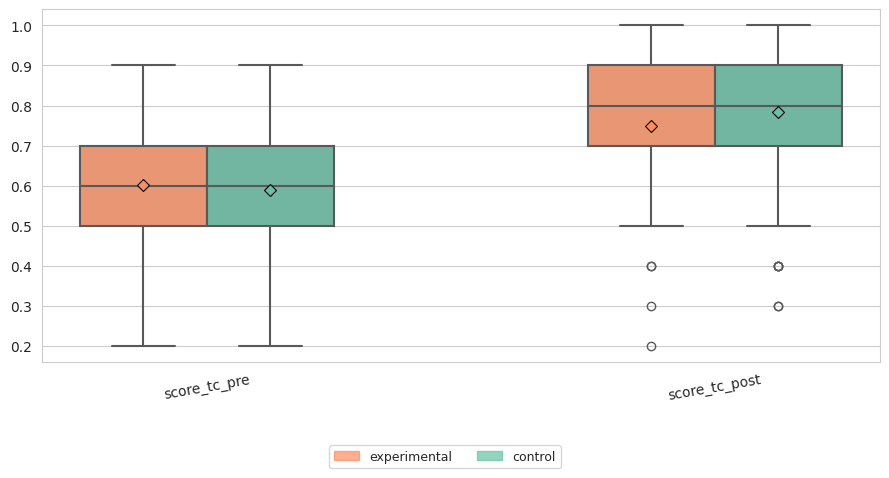

In [284]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_comparison.pdf')
)

In [285]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'

d = df.dropna(subset=[OUTCOME, COVARIATE, 'group', 'school']).copy()

# 1 = experimental: beta1 > 0 significa ventaja del grupo experimental
d['group_binary'] = (d['group'] == 'experimental').astype(int)

pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean

e = d.loc[d['group_binary'] == 1]   # experimental
c = d.loc[d['group_binary'] == 0]   # control
n1, n2 = len(e), len(c)

# ================== DESCRIPTIVOS ==================
print("--- Descriptivos por condición y momento ---")
desc = (d.melt(id_vars='group', value_vars=[COVARIATE, OUTCOME],
               var_name='moment', value_name='score')
          .groupby(['moment', 'group'])['score']
          .agg(n='size', mean='mean', sd='std', median='median',
               q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75),
               min='min', max='max')
          .round(4))
print(desc, "\n")

# ---- Cambio pre-post dentro de cada condición ----
print("--- Cambio pre -> post (crudo) ---")
for lbl, s in [('experimental', e), ('control', c)]:
    delta = s[OUTCOME] - s[COVARIATE]
    print(f"{lbl:<13} mean {s[COVARIATE].mean():.3f} -> {s[OUTCOME].mean():.3f} "
          f"(cambio {delta.mean():+.3f}, SD {delta.std(ddof=1):.3f}) | "
          f"median {s[COVARIATE].median():.2f} -> {s[OUTCOME].median():.2f}")
print(f"\ndiferencia entre condiciones en el cambio medio = "
      f"{(e[OUTCOME]-e[COVARIATE]).mean() - (c[OUTCOME]-c[COVARIATE]).mean():+.4f}")
print(f"diferencia en el post (cruda) = {e[OUTCOME].mean() - c[OUTCOME].mean():+.4f}\n")

# ---- Proporción que mejora / empeora ----
print("--- Dirección del cambio ---")
for lbl, s in [('experimental', e), ('control', c)]:
    delta = s[OUTCOME] - s[COVARIATE]
    print(f"{lbl:<13} mejora {(delta > 0).mean():.1%} | "
          f"igual {(delta == 0).mean():.1%} | empeora {(delta < 0).mean():.1%}")

# ---- Techo y suelo en el post ----
print("\n--- Techo en el post ---")
for lbl, s in [('experimental', e), ('control', c)]:
    print(f"{lbl:<13} en el máximo (1.0): {(s[OUTCOME] == 1.0).sum()} "
          f"({(s[OUTCOME] == 1.0).mean():.1%}) | "
          f">= 0.9: {(s[OUTCOME] >= 0.9).mean():.1%}")

# ---- Cuantiles del post ----
qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("\n--- Cuantiles del post ---")
print(pd.DataFrame({'exp': e[OUTCOME].quantile(qs).round(3),
                    'ctrl': c[OUTCOME].quantile(qs).round(3)}), "\n")

# ---- Relación pre-post y variación entre centros ----
print(f"correlación pre-post: exp r = {e[COVARIATE].corr(e[OUTCOME]):.3f}, "
      f"ctrl r = {c[COVARIATE].corr(c[OUTCOME]):.3f}\n")

school_means = d.groupby('school')[OUTCOME].mean()
print("--- Media del post por centro y condición ---")
print(d.pivot_table(index='school', columns='group',
                    values=OUTCOME, aggfunc=['size', 'mean']).round(4), "\n")
print("media del post por centro:", school_means.round(4).to_dict())
print(f"rango entre centros = {school_means.max() - school_means.min():.4f}\n")

# ================== MODELO M2 ==================
res = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c",
                  data=d, groups=d['school'], re_formula="1").fit(reml=True)

beta1, se1 = res.params['group_binary'], res.bse['group_binary']
p1 = res.pvalues['group_binary']
ci1_lo, ci1_hi = res.conf_int().loc['group_binary']

beta2, se2 = res.params['pre_c'], res.bse['pre_c']
p2 = res.pvalues['pre_c']
ci2_lo, ci2_hi = res.conf_int().loc['pre_c']

var_school, var_resid = float(res.cov_re.iloc[0, 0]), float(res.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

# ---- Hedges' g sobre el post, descriptivo y sin ajustar ----
sp = np.sqrt(((n1 - 1) * e[OUTCOME].std(ddof=1)**2
              + (n2 - 1) * c[OUTCOME].std(ddof=1)**2) / (n1 + n2 - 2))
g = ((e[OUTCOME].mean() - c[OUTCOME].mean()) / sp) * (1 - 3 / (4 * (n1 + n2) - 9))
se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
z = stats.norm.ppf(0.975)

# ================== M3 (exploratorio) ==================
res3 = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c",
                   data=d, groups=d['school'], re_formula="1").fit(reml=True)
b3, se3 = res3.params['group_binary:pre_c'], res3.bse['group_binary:pre_c']
p3 = res3.pvalues['group_binary:pre_c']
ci3_lo, ci3_hi = res3.conf_int().loc['group_binary:pre_c']

# LR test M2 vs M3 (requiere ML, no REML)
m2_ml = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", data=d,
                    groups=d['school'], re_formula="1").fit(reml=False)
m3_ml = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", data=d,
                    groups=d['school'], re_formula="1").fit(reml=False)
lr = 2 * (m3_ml.llf - m2_ml.llf)
p_lr = stats.chi2.sf(lr, 1)

# ---- Salida ----
print("--- Modelo ---")
print(f"OUTCOME = {OUTCOME} | COVARIATE = {COVARIATE} (mean {pre_mean:.4f})")
print(f"n = {n1+n2} (exp {n1}, ctrl {n2}) | schools = {d['school'].nunique()} "
      f"| converged = {res.converged}")
print("M2:")
print(f"  beta1 (group) = {beta1:.4f} (SE {se1:.4f}, p {p1:.4f}, "
      f"95% CI [{ci1_lo:.4f}, {ci1_hi:.4f}])")
print(f"  beta2 (pre_c) = {beta2:.4f} (SE {se2:.4f}, p {p2:.4f}, "
      f"95% CI [{ci2_lo:.4f}, {ci2_hi:.4f}])")
print(f"  ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"  Hedges' g (post, unadjusted) = {g:.4f} "
      f"(95% CI [{g - z*se_g:.4f}, {g + z*se_g:.4f}])")
print("M3 (exploratorio):")
print(f"  beta3 (group x pre_c) = {b3:.4f} (SE {se3:.4f}, p {p3:.4f}, "
      f"95% CI [{ci3_lo:.4f}, {ci3_hi:.4f}])")
print(f"  LR test M2 vs M3: LR = {lr:.4f}, df = 1, p = {p_lr:.4f}")

--- Descriptivos por condición y momento ---
                             n    mean      sd  median   q1   q3  min  max
moment        group                                                       
score_tc_post control       95  0.7842  0.1746     0.8  0.7  0.9  0.3  1.0
              experimental  88  0.7489  0.1640     0.8  0.7  0.9  0.2  1.0
score_tc_pre  control       95  0.5884  0.1809     0.6  0.5  0.7  0.2  0.9
              experimental  88  0.6011  0.1636     0.6  0.5  0.7  0.2  0.9 

--- Cambio pre -> post (crudo) ---
experimental  mean 0.601 -> 0.749 (cambio +0.148, SD 0.205) | median 0.60 -> 0.80
control       mean 0.588 -> 0.784 (cambio +0.196, SD 0.206) | median 0.60 -> 0.80

diferencia entre condiciones en el cambio medio = -0.0481
diferencia en el post (cruda) = -0.0353

--- Dirección del cambio ---
experimental  mejora 71.6% | igual 14.8% | empeora 13.6%
control       mejora 77.9% | igual 8.4% | empeora 13.7%

--- Techo en el post ---
experimental  en el máximo (1.0): 8 

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

--- Modelo ---
OUTCOME = score_tc_post | COVARIATE = score_tc_pre (mean 0.5945)
n = 183 (exp 88, ctrl 95) | schools = 4 | converged = True
M2:
  beta1 (group) = -0.0442 (SE 0.0228, p 0.0526, 95% CI [-0.0889, 0.0005])
  beta2 (pre_c) = 0.2140 (SE 0.0684, p 0.0017, 95% CI [0.0800, 0.3480])
  ICC = 0.2207 (var_school 0.00669, var_resid 0.02362)
  Hedges' g (post, unadjusted) = -0.2076 (95% CI [-0.4983, 0.0832])
M3 (exploratorio):
  beta3 (group x pre_c) = -0.0976 (SE 0.1358, p 0.4725, 95% CI [-0.3638, 0.1687])
  LR test M2 vs M3: LR = 0.5284, df = 1, p = 0.4673


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 2.623792
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter spa

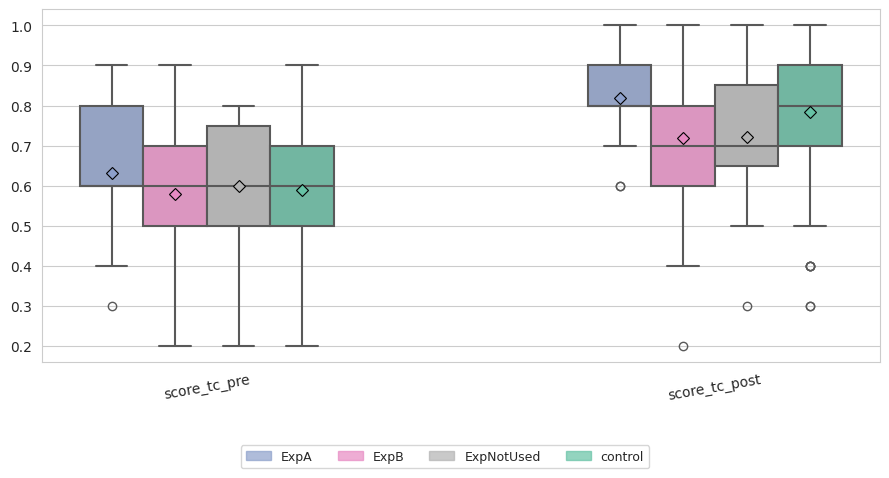

In [286]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_quality.pdf')
)

In [ ]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'
GROUP     = 'group_segmented_quality'
ORDER     = ['control', 'ExpA', 'ExpB', 'ExpNotUsed']   # orden de presentación

d = df.dropna(subset=[OUTCOME, COVARIATE, GROUP, 'school']).copy()
d[GROUP] = d[GROUP].astype(str)

pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean
d['delta'] = d[OUTCOME] - d[COVARIATE]

order = [g for g in ORDER if g in d[GROUP].unique()]

# ================== DESCRIPTIVOS ==================
print("--- Descriptivos por grupo ---")
desc = (d.groupby(GROUP)
          .agg(n=(OUTCOME, 'size'),
               pre_mean=(COVARIATE, 'mean'), pre_sd=(COVARIATE, 'std'),
               pre_median=(COVARIATE, 'median'),
               post_mean=(OUTCOME, 'mean'), post_sd=(OUTCOME, 'std'),
               post_median=(OUTCOME, 'median'),
               change=('delta', 'mean'), change_sd=('delta', 'std'))
          .reindex(order).round(4))
print(desc, "\n")

print("--- Cuartiles por grupo ---")
qt = (d.groupby(GROUP)[[COVARIATE, OUTCOME]]
        .quantile([0.25, 0.5, 0.75]).unstack().reindex(order).round(3))
print(qt, "\n")

print("--- Dirección del cambio ---")
dirn = (d.groupby(GROUP)['delta']
          .agg(improve=lambda s: (s > 0).mean(),
               same=lambda s: (s == 0).mean(),
               worsen=lambda s: (s < 0).mean())
          .reindex(order).round(3))
print(dirn, "\n")

print("--- Techo en el post ---")
ceil = (d.groupby(GROUP)[OUTCOME]
          .agg(at_max=lambda s: (s == 1.0).mean(),
               ge_09=lambda s: (s >= 0.9).mean())
          .reindex(order).round(3))
print(ceil, "\n")

print("--- Distribución de los estratos por centro ---")
print(pd.crosstab(d['school'], d[GROUP]).reindex(columns=order), "\n")


# ================== MODELOS ==================
def fit_with_reference(data, outcome, group, reference, covariate='pre_c',
                       method=None):
    """Ajusta M2 (o M1 si covariate=None) recodificando la referencia del factor."""
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs = f"{term} + {covariate}" if covariate else term
    model = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
    kw = {'method': method} if method is not None else {}
    return model.fit(reml=True, **kw)


def omnibus(data, outcome, group, covariate=None, method=None):
    """LR test del factor de grupo; invariante a la referencia. Requiere ML."""
    term = f"C({group}, Treatment(reference='control'))"
    rhs_full = f"{term} + {covariate}" if covariate else term
    rhs_null = covariate if covariate else "1"
    kw = {'method': method} if method is not None else {}

    def _llf(rhs):
        m = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
        try:
            return m.fit(reml=False, **kw).llf
        except np.linalg.LinAlgError:
            # Hessiano singular: la varianza de grupo está en la frontera.
            # La verosimilitud sí es calculable; se recupera sin errores estándar.
            return m.fit(reml=False, full_output=False, **kw).llf

    lr = 2 * (_llf(rhs_full) - _llf(rhs_null))
    k = data[group].nunique() - 1
    return lr, k, stats.chi2.sf(lr, k)


def print_contrasts(res, reference, label, p_adj=None):
    """Imprime los contrastes del modelo; si se pasa p_adj, añade el p de Holm."""
    print(f"\n--- {label} (reference = {reference}) ---")
    ci = res.conf_int()
    for name in res.params.index:
        if name.startswith('C('):
            lvl = name.split('[T.')[-1].rstrip(']')
            line = (f"{lvl:<12} beta = {res.params[name]:+.4f} "
                    f"(SE {res.bse[name]:.4f}, p {res.pvalues[name]:.4f}, "
                    f"95% CI [{ci.loc[name,0]:+.4f}, {ci.loc[name,1]:+.4f}])")
            if p_adj is not None and lvl in p_adj:
                line += f"  |  p_holm = {p_adj[lvl]:.4f}"
            print(line)


def holm_family(res, label):
    """Aplica Holm a la familia de contrastes frente a la referencia del modelo."""
    names = [n for n in res.params.index if n.startswith('C(')]
    lvls = [n.split('[T.')[-1].rstrip(']') for n in names]
    ps = [res.pvalues[n] for n in names]
    rej, p_adj, _, _ = multipletests(ps, alpha=0.05, method='holm')
    print(f"\n--- Holm correction ({label}, {len(ps)} contrasts) ---")
    for lvl, p, pa, r in zip(lvls, ps, p_adj, rej):
        print(f"{lvl:<12} p = {p:.4f} -> p_holm = {pa:.4f}{'  *' if r else ''}")
    return dict(zip(lvls, p_adj))


# ---- POST ajustado por el pre (M2) ----
res_ctrl = fit_with_reference(d, OUTCOME, GROUP, 'control')
res_expa = fit_with_reference(d, OUTCOME, GROUP, 'ExpA')

var_school, var_resid = float(res_ctrl.cov_re.iloc[0, 0]), float(res_ctrl.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

lr, k_df, p_omni = omnibus(d, OUTCOME, GROUP, covariate='pre_c')

print("=" * 60)
print(f"OUTCOME = {OUTCOME} | COVARIATE = {COVARIATE} (mean {pre_mean:.4f})")
print(f"n = {len(d)} | schools = {d['school'].nunique()} "
      f"| converged = {res_ctrl.converged}")
print(f"group sizes: {d[GROUP].value_counts().reindex(order).to_dict()}")

# Holm sobre la familia de contrastes frente al control
p_holm_post = holm_family(res_ctrl, "POST, vs control")

print_contrasts(res_ctrl, 'control', 'POST, adjusted for prior knowledge',
                p_adj=p_holm_post)
print_contrasts(res_expa, 'ExpA', 'POST, adjusted for prior knowledge '
                                  '(secondary, unadjusted)')

print(f"\npre_c beta = {res_ctrl.params['pre_c']:.4f} "
      f"(SE {res_ctrl.bse['pre_c']:.4f}, p {res_ctrl.pvalues['pre_c']:.4f})")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Omnibus LR test (POST): LR = {lr:.4f}, df = {k_df}, p = {p_omni:.4f}")


# ---- PRE: ¿difieren los estratos ya en el punto de partida? (M1) ----
res_pre_ctrl = fit_with_reference(d, COVARIATE, GROUP, 'control', covariate=None)
res_pre_expa = fit_with_reference(d, COVARIATE, GROUP, 'ExpA',    covariate=None)
lr_p, k_p, p_omni_pre = omnibus(d, COVARIATE, GROUP, covariate=None)

p_holm_pre = holm_family(res_pre_ctrl, "PRE, vs control")

print_contrasts(res_pre_ctrl, 'control', 'PRE, baseline differences (M1)',
                p_adj=p_holm_pre)
print_contrasts(res_pre_expa, 'ExpA', 'PRE, baseline differences (M1) '
                                      '(secondary, unadjusted)')
print(f"\nOmnibus LR test (PRE): LR = {lr_p:.4f}, df = {k_p}, p = {p_omni_pre:.4f}")


# ---- Robustez frente al optimizador (modelo PRE) ----
print("\n--- Robustez del modelo PRE frente al optimizador ---")
for m in [None, ['lbfgs', 'bfgs', 'cg'], ['cg', 'bfgs'], ['powell', 'bfgs']]:
    lbl = 'default' if m is None else '+'.join(m)
    try:
        r = fit_with_reference(d, COVARIATE, GROUP, 'control',
                               covariate=None, method=m)
        betas = {n.split('[T.')[-1].rstrip(']'): round(r.params[n], 4)
                 for n in r.params.index if n.startswith('C(')}
        print(f"{lbl:<18} converged={r.converged} "
              f"| var_school={float(r.cov_re.iloc[0,0]):.6f} | betas={betas}")
    except Exception as exc:
        print(f"{lbl:<18} falló: {type(exc).__name__}: {exc}")


# ---- Sensibilidad: excluyendo el centro que concentra los no usuarios ----
EXCLUDE = 'RamiroMaeztu'
d_sens = d[d['school'] != EXCLUDE]
res_sens = fit_with_reference(d_sens, OUTCOME, GROUP, 'control')
print(f"\n[sensibilidad] n = {len(d_sens)} | "
      f"tamaños: {d_sens[GROUP].value_counts().reindex(order).to_dict()}")
print_contrasts(res_sens, 'control', f'POST, excluding {EXCLUDE}')

--- Descriptivos por grupo ---
                          n  pre_mean  pre_sd  pre_median  post_mean  post_sd  \
group_segmented_quality                                                         
control                  95    0.5884  0.1809         0.6     0.7842   0.1746   
ExpA                     25    0.6320  0.1492         0.6     0.8200   0.1080   
ExpB                     36    0.5806  0.1754         0.6     0.7194   0.1802   
ExpNotUsed               27    0.6000  0.1617         0.6     0.7222   0.1695   

                         post_median  change  change_sd  
group_segmented_quality                                  
control                          0.8  0.1958     0.2062  
ExpA                             0.8  0.1880     0.1787  
ExpB                             0.7  0.1389     0.2321  
ExpNotUsed                       0.7  0.1222     0.1888   

--- Cuartiles por grupo ---
                        score_tc_pre            score_tc_post           
                               

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(

OUTCOME = score_tc_post | COVARIATE = score_tc_pre (mean 0.5945)
n = 183 | schools = 4 | converged = True
group sizes: {'control': 95, 'ExpA': 25, 'ExpB': 36, 'ExpNotUsed': 27}

--- Holm correction (POST, vs control, 3 contrasts) ---
ExpA         p = 0.6627 -> p_holm = 0.6627
ExpB         p = 0.0435 -> p_holm = 0.0869
ExpNotUsed   p = 0.0273 -> p_holm = 0.0818

--- POST, adjusted for prior knowledge (reference = control) ---
ExpA         beta = +0.0154 (SE 0.0352, p 0.6627, 95% CI [-0.0536, +0.0843])  |  p_holm = 0.6627
ExpB         beta = -0.0606 (SE 0.0300, p 0.0435, 95% CI [-0.1193, -0.0018])  |  p_holm = 0.0869
ExpNotUsed   beta = -0.0766 (SE 0.0347, p 0.0273, 95% CI [-0.1446, -0.0086])  |  p_holm = 0.0818

--- POST, adjusted for prior knowledge (secondary, unadjusted) (reference = ExpA) ---
ExpB         beta = -0.0759 (SE 0.0403, p 0.0599, 95% CI [-0.1550, +0.0032])
ExpNotUsed   beta = -0.0920 (SE 0.0453, p 0.0425, 95% CI [-0.1808, -0.0031])
control      beta = -0.0154 (SE 0.0352,

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat


--- Holm correction (PRE, vs control, 3 contrasts) ---
ExpA         p = 0.3002 -> p_holm = 0.9005
ExpB         p = 0.8637 -> p_holm = 1.0000
ExpNotUsed   p = 0.9363 -> p_holm = 1.0000

--- PRE, baseline differences (M1) (reference = control) ---
ExpA         beta = +0.0401 (SE 0.0387, p 0.3002, 95% CI [-0.0357, +0.1158])  |  p_holm = 0.9005
ExpB         beta = -0.0057 (SE 0.0332, p 0.8637, 95% CI [-0.0707, +0.0593])  |  p_holm = 1.0000
ExpNotUsed   beta = +0.0031 (SE 0.0382, p 0.9363, 95% CI [-0.0718, +0.0779])  |  p_holm = 1.0000

--- PRE, baseline differences (M1) (secondary, unadjusted) (reference = ExpA) ---
ExpB         beta = -0.0457 (SE 0.0444, p 0.3031, 95% CI [-0.1328, +0.0413])
ExpNotUsed   beta = -0.0370 (SE 0.0495, p 0.4547, 95% CI [-0.1340, +0.0600])
control      beta = -0.0401 (SE 0.0387, p 0.3002, 95% CI [-0.1158, +0.0357])

Omnibus LR test (PRE): LR = 1.3271, df = 3, p = 0.7227

--- Robustez del modelo PRE frente al optimizador ---
default            converged=True | v

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/fabio/fabio_scielzo_ortiz/va-educatio

cg+bfgs            converged=False | var_school=0.001816 | betas={'ExpA': np.float64(0.0401), 'ExpB': np.float64(-0.0057), 'ExpNotUsed': np.float64(0.0031)}
powell+bfgs        converged=True | var_school=0.001753 | betas={'ExpA': np.float64(0.0401), 'ExpB': np.float64(-0.0057), 'ExpNotUsed': np.float64(0.0031)}

[sensibilidad] n = 120 | tamaños: {'control': 64, 'ExpA': 21, 'ExpB': 27, 'ExpNotUsed': 8}

--- POST, excluding RamiroMaeztu (reference = control) ---
ExpA         beta = +0.0199 (SE 0.0428, p 0.6417, 95% CI [-0.0640, +0.1038])
ExpB         beta = -0.0684 (SE 0.0384, p 0.0748, 95% CI [-0.1436, +0.0068])
ExpNotUsed   beta = -0.0775 (SE 0.0637, p 0.2240, 95% CI [-0.2024, +0.0474])


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


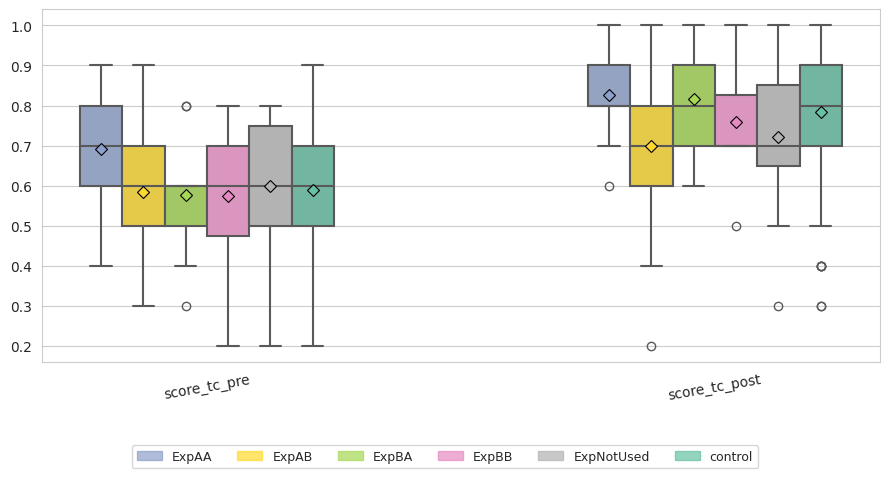

In [288]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group_segmented_freq_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_freq_quality.pdf')
)

In [289]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'
GROUP     = 'group_segmented_freq_quality'
ORDER     = ['control', 'ExpAA', 'ExpBA', 'ExpAB', 'ExpBB', 'ExpNotUsed']

d = df.dropna(subset=[OUTCOME, COVARIATE, GROUP, 'school']).copy()
d[GROUP] = d[GROUP].astype(str)

pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean
d['delta'] = d[OUTCOME] - d[COVARIATE]

order = [g for g in ORDER if g in d[GROUP].unique()]
missing = set(d[GROUP].unique()) - set(ORDER)
if missing:
    print(f"[aviso] niveles no contemplados en ORDER: {missing}\n")

# ================== DESCRIPTIVOS ==================
print("--- Descriptivos por grupo ---")
desc = (d.groupby(GROUP)
          .agg(n=(OUTCOME, 'size'),
               pre_mean=(COVARIATE, 'mean'), pre_sd=(COVARIATE, 'std'),
               pre_median=(COVARIATE, 'median'),
               post_mean=(OUTCOME, 'mean'), post_sd=(OUTCOME, 'std'),
               post_median=(OUTCOME, 'median'),
               change=('delta', 'mean'), change_sd=('delta', 'std'))
          .reindex(order).round(4))
print(desc, "\n")

print("--- Cuartiles por grupo ---")
qt = (d.groupby(GROUP)[[COVARIATE, OUTCOME]]
        .quantile([0.25, 0.5, 0.75]).unstack().reindex(order).round(3))
print(qt, "\n")

print("--- Dirección del cambio ---")
dirn = (d.groupby(GROUP)['delta']
          .agg(improve=lambda s: (s > 0).mean(),
               same=lambda s: (s == 0).mean(),
               worsen=lambda s: (s < 0).mean())
          .reindex(order).round(3))
print(dirn, "\n")

print("--- Techo en el post ---")
ceil = (d.groupby(GROUP)[OUTCOME]
          .agg(at_max=lambda s: (s == 1.0).mean(),
               ge_09=lambda s: (s >= 0.9).mean())
          .reindex(order).round(3))
print(ceil, "\n")

print("--- Distribución de los estratos por centro ---")
print(pd.crosstab(d['school'], d[GROUP]).reindex(columns=order), "\n")


# ================== MODELOS ==================
def fit_with_reference(data, outcome, group, reference, covariate='pre_c',
                       method=None):
    """Ajusta M2 (o M1 si covariate=None) recodificando la referencia del factor."""
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs = f"{term} + {covariate}" if covariate else term
    model = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
    kw = {'method': method} if method is not None else {}
    return model.fit(reml=True, **kw)


def omnibus(data, outcome, group, covariate=None, method=None,
            reference='control'):
    """LR test del factor de grupo; invariante a la referencia. Requiere ML."""
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs_full = f"{term} + {covariate}" if covariate else term
    rhs_null = covariate if covariate else "1"
    kw = {'method': method} if method is not None else {}

    def _llf(rhs):
        m = smf.mixedlm(f"{outcome} ~ {rhs}", data=data,
                        groups=data['school'], re_formula="1")
        try:
            return m.fit(reml=False, **kw).llf
        except np.linalg.LinAlgError:
            return m.fit(reml=False, full_output=False, **kw).llf

    lr = 2 * (_llf(rhs_full) - _llf(rhs_null))
    k = data[group].nunique() - 1
    return lr, k, stats.chi2.sf(lr, k)


def print_contrasts(res, reference, label, p_adj=None):
    print(f"\n--- {label} (reference = {reference}) ---")
    ci = res.conf_int()
    for name in res.params.index:
        if name.startswith('C('):
            lvl = name.split('[T.')[-1].rstrip(']')
            line = (f"{lvl:<12} beta = {res.params[name]:+.4f} "
                    f"(SE {res.bse[name]:.4f}, p {res.pvalues[name]:.4f}, "
                    f"95% CI [{ci.loc[name,0]:+.4f}, {ci.loc[name,1]:+.4f}])")
            if p_adj is not None and lvl in p_adj:
                line += f"  |  p_holm = {p_adj[lvl]:.4f}"
            print(line)


def holm_family(res, label):
    names = [n for n in res.params.index if n.startswith('C(')]
    lvls = [n.split('[T.')[-1].rstrip(']') for n in names]
    ps = [res.pvalues[n] for n in names]
    rej, p_adj, _, _ = multipletests(ps, alpha=0.05, method='holm')
    print(f"\n--- Holm correction ({label}, {len(ps)} contrasts) ---")
    for lvl, p, pa, r in zip(lvls, ps, p_adj, rej):
        print(f"{lvl:<12} p = {p:.4f} -> p_holm = {pa:.4f}{'  *' if r else ''}")
    return dict(zip(lvls, p_adj))


# ---- POST ajustado por el pre (M2) ----
res_ctrl = fit_with_reference(d, OUTCOME, GROUP, 'control')

var_school, var_resid = float(res_ctrl.cov_re.iloc[0, 0]), float(res_ctrl.scale)
icc = var_school / (var_school + var_resid)
if var_school < 1e-8:
    print("[aviso] varianza de centro prácticamente nula: ajuste singular.")

lr, k_df, p_omni = omnibus(d, OUTCOME, GROUP, covariate='pre_c')

print("=" * 60)
print(f"OUTCOME = {OUTCOME} | COVARIATE = {COVARIATE} (mean {pre_mean:.4f})")
print(f"n = {len(d)} | schools = {d['school'].nunique()} "
      f"| converged = {res_ctrl.converged}")
print(f"group sizes: {d[GROUP].value_counts().reindex(order).to_dict()}")

p_holm_post = holm_family(res_ctrl, "POST, vs control")
print_contrasts(res_ctrl, 'control', 'POST, adjusted for prior knowledge',
                p_adj=p_holm_post)

print(f"\npre_c beta = {res_ctrl.params['pre_c']:.4f} "
      f"(SE {res_ctrl.bse['pre_c']:.4f}, p {res_ctrl.pvalues['pre_c']:.4f})")
print(f"ICC = {icc:.4f} (var_school {var_school:.5f}, var_resid {var_resid:.5f})")
print(f"Omnibus LR test (POST): LR = {lr:.4f}, df = {k_df}, p = {p_omni:.4f}")

# Referencia secundaria: el estrato de mayor calidad y mayor frecuencia
if 'ExpAA' in order:
    res_expaa = fit_with_reference(d, OUTCOME, GROUP, 'ExpAA')
    print_contrasts(res_expaa, 'ExpAA', 'POST (secondary, unadjusted)')


# ---- PRE: ¿difieren los estratos en el punto de partida? (M1) ----
res_pre_ctrl = fit_with_reference(d, COVARIATE, GROUP, 'control', covariate=None)
lr_p, k_p, p_omni_pre = omnibus(d, COVARIATE, GROUP, covariate=None)

p_holm_pre = holm_family(res_pre_ctrl, "PRE, vs control")
print_contrasts(res_pre_ctrl, 'control', 'PRE, baseline differences (M1)',
                p_adj=p_holm_pre)
print(f"\nOmnibus LR test (PRE): LR = {lr_p:.4f}, df = {k_p}, p = {p_omni_pre:.4f}")


# ---- Contraste dirigido: ¿importa la frecuencia dentro de cada nivel de calidad? ----
# Compara ExpAA vs ExpBA (alta calidad, alta vs baja frecuencia)
#       y ExpAB vs ExpBB (baja calidad, alta vs baja frecuencia)
print("\n--- Efecto de la frecuencia dentro de cada nivel de calidad ---")
for ref, other, lbl in [('ExpBA', 'ExpAA', 'high quality: high vs low frequency'),
                        ('ExpBB', 'ExpAB', 'low quality: high vs low frequency')]:
    if ref in order and other in order:
        r = fit_with_reference(d, OUTCOME, GROUP, ref)
        name = [n for n in r.params.index
                if n.startswith('C(') and n.endswith(f'[T.{other}]')]
        if name:
            n0 = name[0]
            ci = r.conf_int().loc[n0]
            print(f"{lbl:<38} {other} vs {ref}: beta = {r.params[n0]:+.4f} "
                  f"(p {r.pvalues[n0]:.4f}, 95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}])")

--- Descriptivos por grupo ---
                               n  pre_mean  pre_sd  pre_median  post_mean  \
group_segmented_freq_quality                                                
control                       95    0.5884  0.1809         0.6     0.7842   
ExpAA                         12    0.6917  0.1443         0.7     0.8250   
ExpBA                         13    0.5769  0.1363         0.6     0.8154   
ExpAB                         24    0.5833  0.1711         0.6     0.7000   
ExpBB                         12    0.5750  0.1913         0.6     0.7583   
ExpNotUsed                    27    0.6000  0.1617         0.6     0.7222   

                              post_sd  post_median  change  change_sd  
group_segmented_freq_quality                                           
control                        0.1746          0.8  0.1958     0.2062  
ExpAA                          0.1055          0.8  0.1333     0.1723  
ExpBA                          0.1144          0.8  0.2385     0

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

OUTCOME = score_tc_post | COVARIATE = score_tc_pre (mean 0.5945)
n = 183 | schools = 4 | converged = True
group sizes: {'control': 95, 'ExpAA': 12, 'ExpBA': 13, 'ExpAB': 24, 'ExpBB': 12, 'ExpNotUsed': 27}

--- Holm correction (POST, vs control, 5 contrasts) ---
ExpAA        p = 0.8193 -> p_holm = 1.0000
ExpAB        p = 0.0142 -> p_holm = 0.0712
ExpBA        p = 0.6931 -> p_holm = 1.0000
ExpBB        p = 0.8296 -> p_holm = 1.0000
ExpNotUsed   p = 0.0279 -> p_holm = 0.1116

--- POST, adjusted for prior knowledge (reference = control) ---
ExpAA        beta = +0.0110 (SE 0.0481, p 0.8193, 95% CI [-0.0833, +0.1053])  |  p_holm = 1.0000
ExpAB        beta = -0.0859 (SE 0.0350, p 0.0142, 95% CI [-0.1545, -0.0172])  |  p_holm = 0.0712
ExpBA        beta = +0.0180 (SE 0.0457, p 0.6931, 95% CI [-0.0715, +0.1075])  |  p_holm = 1.0000
ExpBB        beta = -0.0101 (SE 0.0469, p 0.8296, 95% CI [-0.1021, +0.0819])  |  p_holm = 1.0000
ExpNotUsed   beta = -0.0763 (SE 0.0347, p 0.0279, 95% CI [-0.1443, -0

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


--- Holm correction (PRE, vs control, 5 contrasts) ---
ExpAA        p = 0.0516 -> p_holm = 0.2578
ExpAB        p = 0.9114 -> p_holm = 1.0000
ExpBA        p = 0.7486 -> p_holm = 1.0000
ExpBB        p = 0.8778 -> p_holm = 1.0000
ExpNotUsed   p = 0.9553 -> p_holm = 1.0000

--- PRE, baseline differences (M1) (reference = control) ---
ExpAA        beta = +0.1019 (SE 0.0524, p 0.0516, 95% CI [-0.0007, +0.2046])  |  p_holm = 0.2578
ExpAB        beta = -0.0043 (SE 0.0386, p 0.9114, 95% CI [-0.0800, +0.0714])  |  p_holm = 1.0000
ExpBA        beta = -0.0161 (SE 0.0502, p 0.7486, 95% CI [-0.1146, +0.0824])  |  p_holm = 1.0000
ExpBB        beta = -0.0080 (SE 0.0518, p 0.8778, 95% CI [-0.1095, +0.0936])  |  p_holm = 1.0000
ExpNotUsed   beta = +0.0021 (SE 0.0381, p 0.9553, 95% CI [-0.0725, +0.0768])  |  p_holm = 1.0000

Omnibus LR test (PRE): LR = 4.4212, df = 5, p = 0.4905

--- Efecto de la frecuencia dentro de cada nivel de calidad ---
high quality: high vs low frequency    ExpAA vs ExpBA: beta =

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


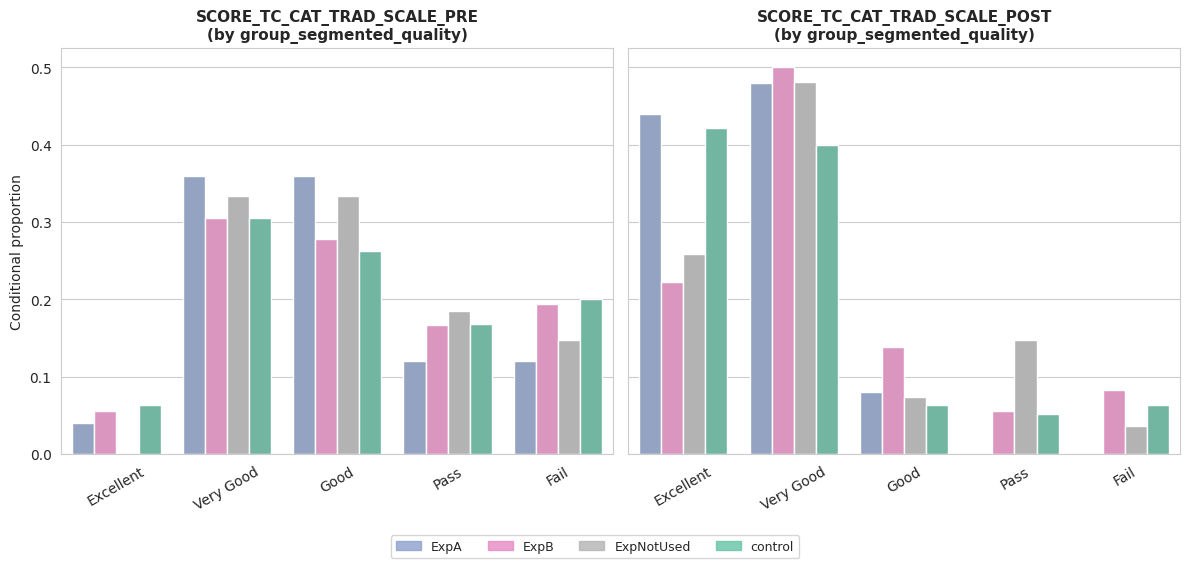

In [290]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['score_tc_cat_trad_scale_pre'], ['score_tc_cat_trad_scale_post'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.14),
    group_by='group_segmented_quality',
    sharey=True,
    order=['Excellent', 'Very Good', 'Good', 'Pass', 'Fail'],
    subplots_title=True,
    save_path=os.path.join(knowledge_path, 'pre_post_trad_scale.pdf')
)

In [291]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

PRE_CAT   = 'score_tc_cat_trad_scale_pre'
POST_CAT  = 'score_tc_cat_trad_scale_post'
GROUP     = 'group_segmented_quality'
ORDER     = ['control', 'ExpA', 'ExpB', 'ExpNotUsed']
LEVELS    = ['Fail', 'Pass', 'Good', 'Very Good', 'Excellent']   # de peor a mejor

d = df.dropna(subset=[PRE_CAT, POST_CAT, GROUP, 'school']).copy()
d[GROUP] = d[GROUP].astype(str)
order = [g for g in ORDER if g in d[GROUP].unique()]

d['pass_pre']  = (~d[PRE_CAT].isin(['Fail', 'Pass'])).astype(int)
d['pass_post'] = (~d[POST_CAT].isin(['Fail', 'Pass'])).astype(int)
d['high_pre']  = d[PRE_CAT].isin(['Very Good', 'Excellent']).astype(int)
d['high_post'] = d[POST_CAT].isin(['Very Good', 'Excellent']).astype(int)

# ================== DESCRIPTIVOS ==================
print("--- Distribución de grados (proporciones por grupo) ---")
for lbl, col in [('PRE', PRE_CAT), ('POST', POST_CAT)]:
    tab = (pd.crosstab(d[GROUP], d[col], normalize='index')
             .reindex(index=order, columns=LEVELS).round(3))
    print(f"\n{lbl}:\n{tab}")

print("\n--- Recuentos absolutos (POST) ---")
print(pd.crosstab(d[GROUP], d[POST_CAT]).reindex(index=order, columns=LEVELS), "\n")

print("--- Umbrales binarios (proporciones) ---")
thr = (d.groupby(GROUP)[['pass_pre', 'pass_post', 'high_pre', 'high_post']]
         .mean().reindex(order).round(3))
thr['n'] = d.groupby(GROUP).size().reindex(order)
print(thr, "\n")

print("--- Movimiento de categoría (pre -> post) ---")
rank = {lvl: i for i, lvl in enumerate(LEVELS)}
d['cat_move'] = d[POST_CAT].map(rank) - d[PRE_CAT].map(rank)
mv = (d.groupby(GROUP)['cat_move']
        .agg(up=lambda s: (s > 0).mean(),
             same=lambda s: (s == 0).mean(),
             down=lambda s: (s < 0).mean(),
             mean_shift='mean')
        .reindex(order).round(3))
print(mv, "\n")


# ================== MODELOS ==================
# Regresión de Poisson modificada (GEE, enlace log, errores robustos):
# estima riesgos relativos, preferibles al OR con desenlaces frecuentes.
# El umbral de aprobado no es modelable (0% de ExpA por debajo -> separación completa).
def fit_gee(data, outcome, group, reference, covariate='high_pre',
            family='poisson', cov='exchangeable'):
    term = f"C({group}, Treatment(reference='{reference}'))"
    rhs = f"{term} + {covariate}" if covariate else term
    fam = (sm.families.Poisson() if family == 'poisson'
           else sm.families.Binomial())
    cs = Exchangeable() if cov == 'exchangeable' else Independence()
    return GEE.from_formula(f"{outcome} ~ {rhs}", groups='school', data=data,
                            family=fam, cov_struct=cs).fit()


def print_gee(res, reference, label, measure='RR', p_adj=None):
    print(f"\n--- {label} (reference = {reference}) ---")
    ci = res.conf_int()
    for name in res.params.index:
        if name.startswith('C('):
            lvl = name.split('[T.')[-1].rstrip(']')
            est, lo, hi = (np.exp(res.params[name]),
                           np.exp(ci.loc[name, 0]), np.exp(ci.loc[name, 1]))
            line = (f"{lvl:<12} beta = {res.params[name]:+.4f} | "
                    f"{measure} = {est:.3f} (95% CI [{lo:.3f}, {hi:.3f}]) | "
                    f"p = {res.pvalues[name]:.4f}")
            if p_adj is not None and lvl in p_adj:
                line += f"  |  p_holm = {p_adj[lvl]:.4f}"
            print(line)


def holm_gee(res, label):
    names = [n for n in res.params.index if n.startswith('C(')]
    lvls = [n.split('[T.')[-1].rstrip(']') for n in names]
    ps = [res.pvalues[n] for n in names]
    _, p_adj, _, _ = multipletests(ps, alpha=0.05, method='holm')
    print(f"\n--- Holm correction ({label}, {len(ps)} contrasts) ---")
    for lvl, p, pa in zip(lvls, ps, p_adj):
        print(f"{lvl:<12} p = {p:.4f} -> p_holm = {pa:.4f}")
    return dict(zip(lvls, p_adj))


print("=" * 60)
print(f"n = {len(d)} | schools = {d['school'].nunique()}")
print(f"group sizes: {d[GROUP].value_counts().reindex(order).to_dict()}")

# ---- Principal: RR con referencia control (familia corregida por Holm) ----
res_ctrl = fit_gee(d, 'high_post', GROUP, 'control')
p_holm = holm_gee(res_ctrl, "POST high grade, vs control")
print_gee(res_ctrl, 'control',
          'POST: P(Very Good or Excellent), adjusted for baseline grade [RR]',
          measure='RR', p_adj=p_holm)
print(f"\nhigh_pre beta = {res_ctrl.params['high_pre']:+.4f} "
      f"(RR {np.exp(res_ctrl.params['high_pre']):.3f}, "
      f"p {res_ctrl.pvalues['high_pre']:.4f})")

# ---- Secundario: mismos contrastes con referencia ExpA (sin corregir) ----
res_expa = fit_gee(d, 'high_post', GROUP, 'ExpA')
print_gee(res_expa, 'ExpA',
          'POST: P(Very Good or Excellent), adjusted for baseline grade [RR] '
          '(secondary contrasts, no multiplicity correction)',
          measure='RR')

# ---- Baseline: ¿difieren los estratos en el grado previo? ----
res_pre_ctrl = fit_gee(d, 'high_pre', GROUP, 'control', covariate=None)
res_pre_expa = fit_gee(d, 'high_pre', GROUP, 'ExpA', covariate=None)
print_gee(res_pre_ctrl, 'control',
          'PRE: P(Very Good or Excellent) [RR] (no covariate)', measure='RR')
print_gee(res_pre_expa, 'ExpA',
          'PRE: P(Very Good or Excellent) [RR] (no covariate, secondary)',
          measure='RR')

# ---- Robustez 1: escala de odds (especificación logística) ----
res_or = fit_gee(d, 'high_post', GROUP, 'control', family='binomial')
print_gee(res_or, 'control',
          'POST: logistic specification (robustness) [OR]', measure='OR')

# ---- Robustez 2: estructura de correlación independiente ----
# Con solo 4 clusters, los errores robustos pueden ser anticonservadores.
# Comparar ambas estructuras indica cuánta precisión depende del supuesto.
res_ind = fit_gee(d, 'high_post', GROUP, 'control', cov='independence')
print_gee(res_ind, 'control',
          'POST: independence working correlation (robustness) [RR]',
          measure='RR')

print("\n--- Anchura de los IC: exchangeable vs independence ---")
ci_e, ci_i = res_ctrl.conf_int(), res_ind.conf_int()
for name in res_ctrl.params.index:
    if name.startswith('C('):
        lvl = name.split('[T.')[-1].rstrip(']')
        we = np.exp(ci_e.loc[name, 1]) - np.exp(ci_e.loc[name, 0])
        wi = np.exp(ci_i.loc[name, 1]) - np.exp(ci_i.loc[name, 0])
        print(f"{lvl:<12} exchangeable = {we:.3f} | independence = {wi:.3f} "
              f"| ratio = {wi/we:.2f}")

# ---- Comprobación descriptiva: chi-cuadrado sobre la tabla completa ----
print("\n--- Chi-square on the full 4x5 table (descriptive check) ---")
for lbl, col in [('PRE', PRE_CAT), ('POST', POST_CAT)]:
    tab = pd.crosstab(d[GROUP], d[col]).reindex(index=order, columns=LEVELS).fillna(0)
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    n_small = (exp < 5).sum()
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    print(f"{lbl}: chi2 = {chi2:.3f}, df = {dof}, p = {p:.4f}, "
          f"Cramer's V = {v:.3f} | celdas con esperada < 5: {n_small}/{exp.size}")

--- Distribución de grados (proporciones por grupo) ---

PRE:
score_tc_cat_trad_scale_pre   Fail   Pass   Good  Very Good  Excellent
group_segmented_quality                                               
control                      0.200  0.168  0.263      0.305      0.063
ExpA                         0.120  0.120  0.360      0.360      0.040
ExpB                         0.194  0.167  0.278      0.306      0.056
ExpNotUsed                   0.148  0.185  0.333      0.333      0.000

POST:
score_tc_cat_trad_scale_post   Fail   Pass   Good  Very Good  Excellent
group_segmented_quality                                                
control                       0.063  0.053  0.063      0.400      0.421
ExpA                          0.000  0.000  0.080      0.480      0.440
ExpB                          0.083  0.056  0.139      0.500      0.222
ExpNotUsed                    0.037  0.148  0.074      0.481      0.259

--- Recuentos absolutos (POST) ---
score_tc_cat_trad_scale_post  Fail  P

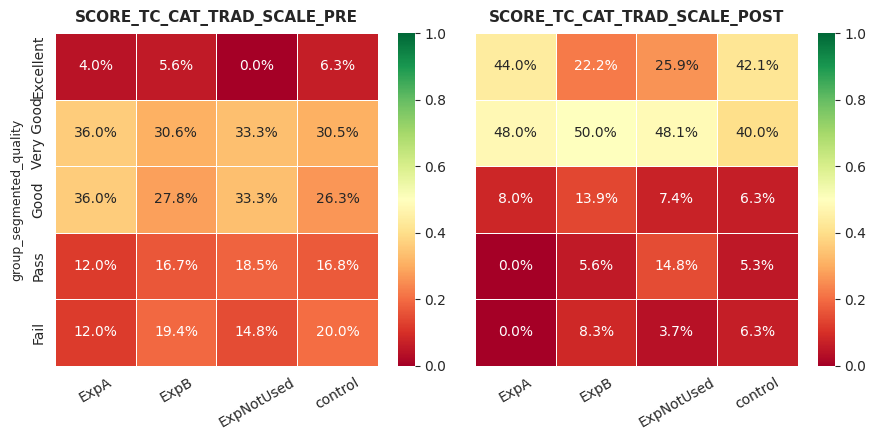

In [292]:
plot_cat_comparison_heatmap(
    df=forms_interactions_df,
    comparisons=[
        ['score_tc_cat_trad_scale_pre'], ['score_tc_cat_trad_scale_post'],
    ],
    group_by='group_segmented_quality',
    order=['Excellent', 'Very Good', 'Good', 'Pass', 'Fail'],
    title=None
)

EXPERIMENTAL:


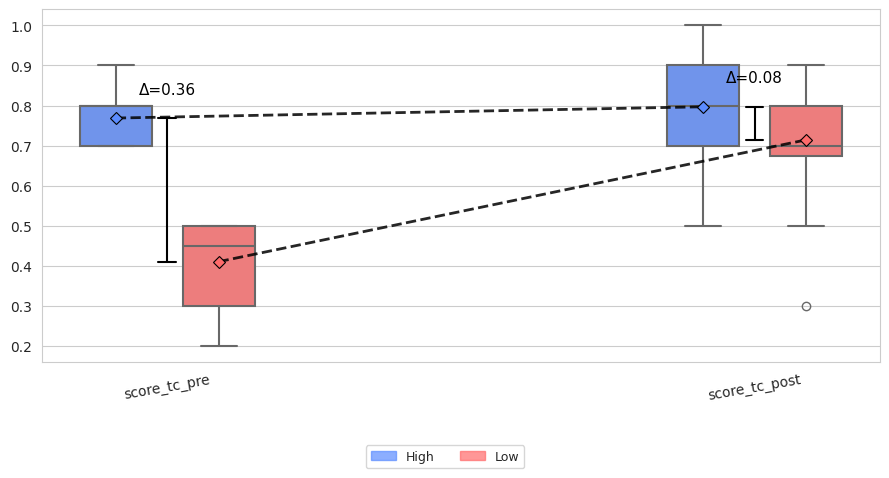

CONTROL:


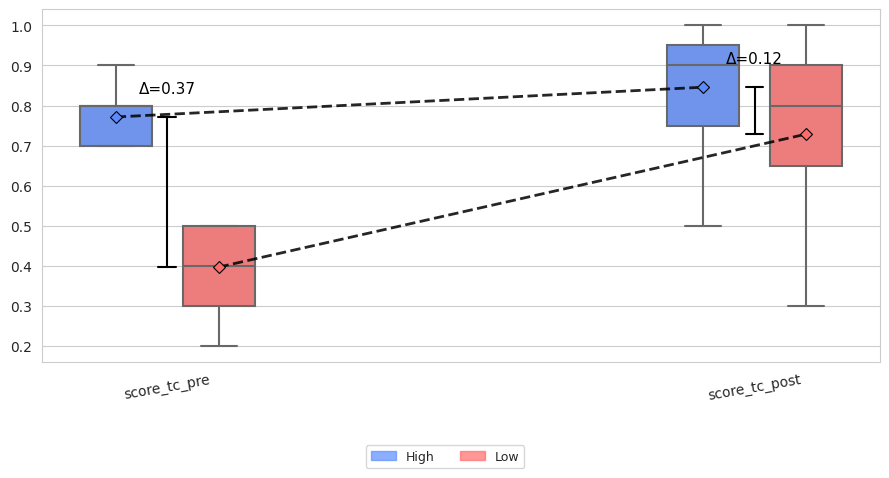

In [293]:
# Categorización adicional según el group al que pertenecen (solo para score_tc)
col = 'score_tc_pre'
df_cat_group = (
    forms_interactions_df.with_columns(
        pl.when(pl.col(col) <= 0.5).then(pl.lit("Low"))
        .when(pl.col(col) >= 0.7).then(pl.lit("High"))
        .alias(f"{col}_cat_new_group")
    )
)

df_cat_group_exp = df_cat_group.filter(
    pl.col("group") == "experimental"
)
df_cat_group_control = df_cat_group.filter(
    pl.col("group") == "control"
)

print("EXPERIMENTAL:")
plot_quant_comparison(
    figsize=(9, 4),
    df=df_cat_group_exp,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by=f"{col}_cat_new_group",
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    show_mean_lines=True,
    save_path=os.path.join(knowledge_path, 'mathew_experimental.pdf')
)

print("CONTROL:")
plot_quant_comparison(
    figsize=(9, 4),
    df=df_cat_group_control,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by=f"{col}_cat_new_group",
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    show_mean_lines=True,
    save_path=os.path.join(knowledge_path, 'mathew_control.pdf')
)

EXPNOTUSED


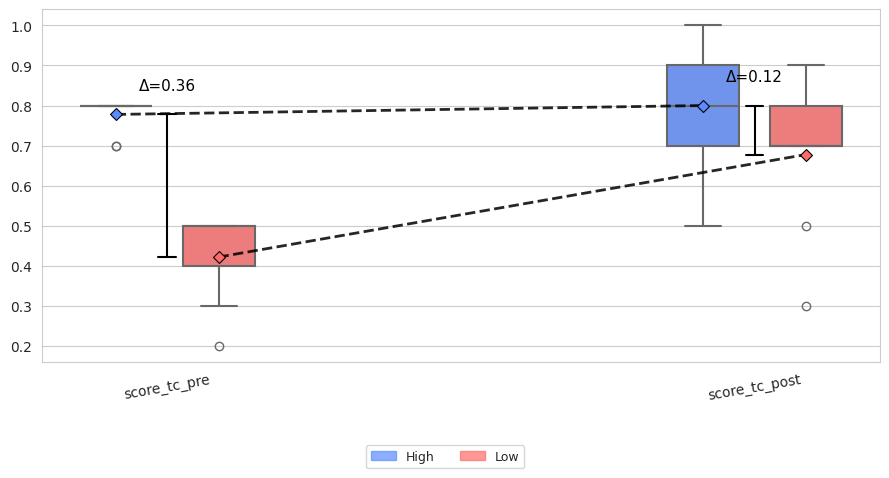

EXPB


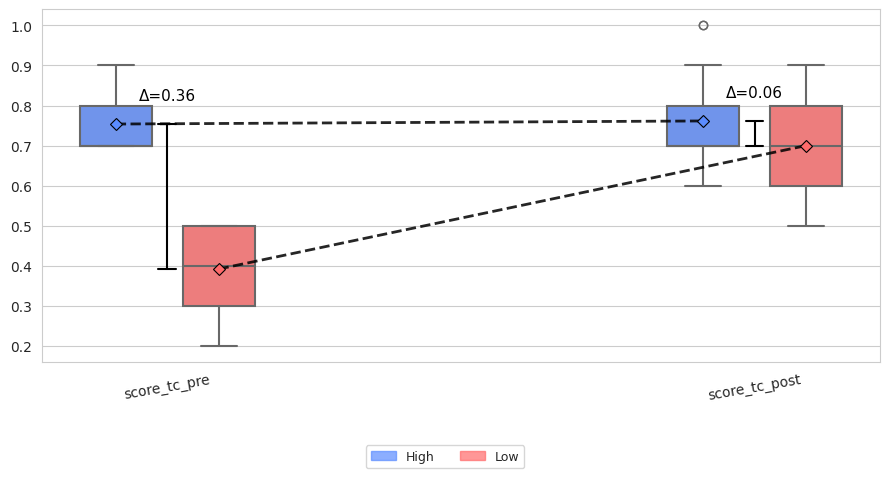

EXPA


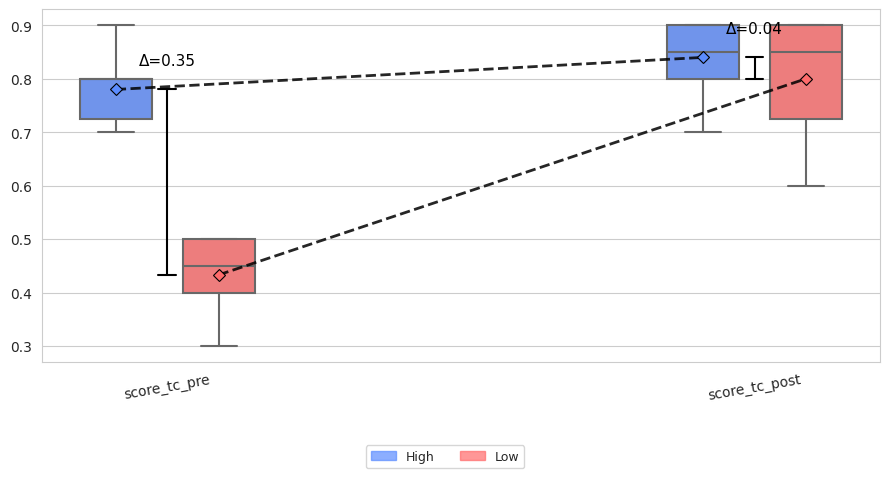

In [294]:
variable = "experimental_type_quality"

for g in df_cat_group_exp[variable].unique().to_list():
    print(g.upper())
    plot_quant_comparison(
        figsize=(9, 4),
        df=df_cat_group_exp.filter(
            pl.col(variable)==g
        ),
        comparisons=[
            ["score_tc_pre", "score_tc_post"]
        ],
        group_by=f"{col}_cat_new_group",
        showfliers=True,
        title=None,
        labelbottom=True,
        xlabel_rotation=10,
        bbox_to_anchor=(0.5, -0.2),
        show_mean_lines=True,
        save_path=os.path.join(knowledge_path, f'mathew_{g}.pdf')
    )

EXPAB


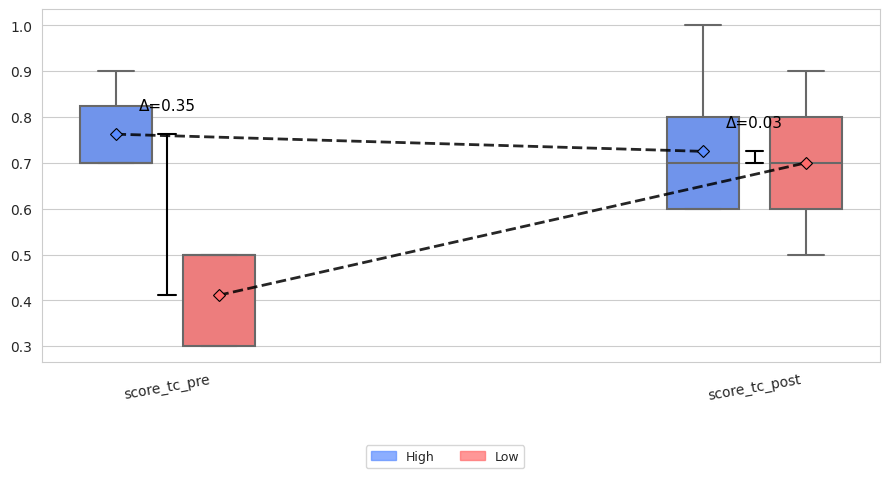

EXPAA


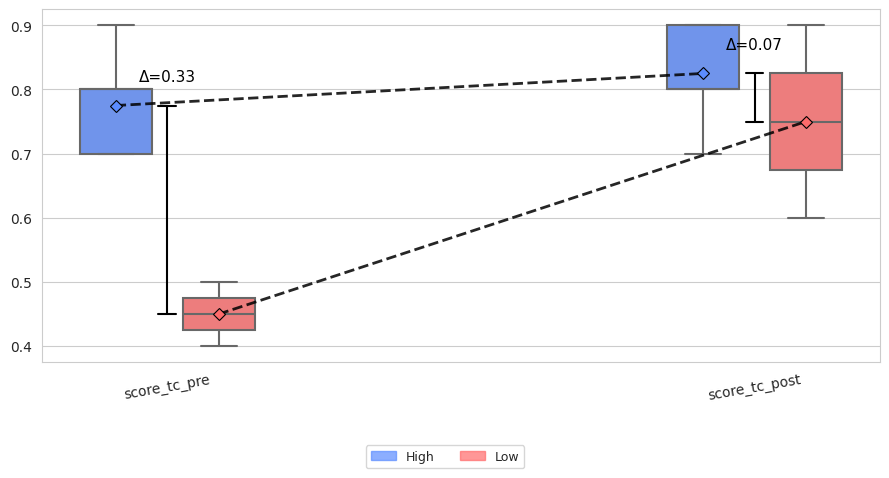

EXPBB


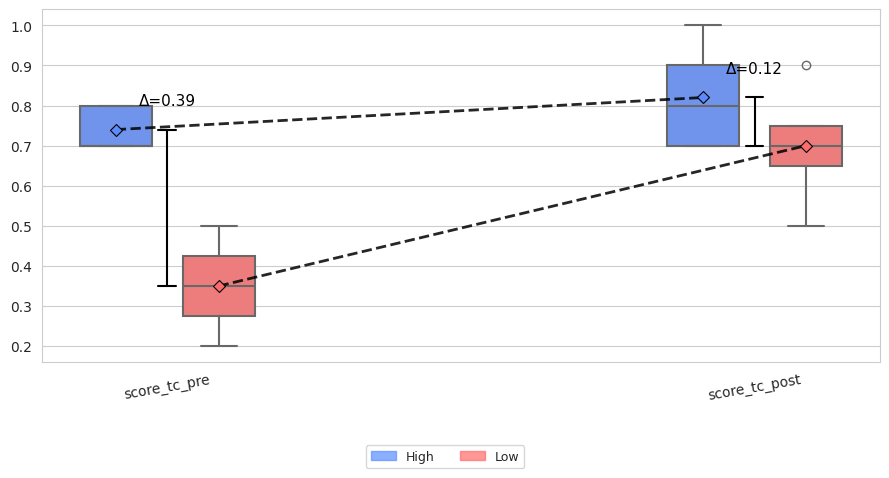

EXPNOTUSED


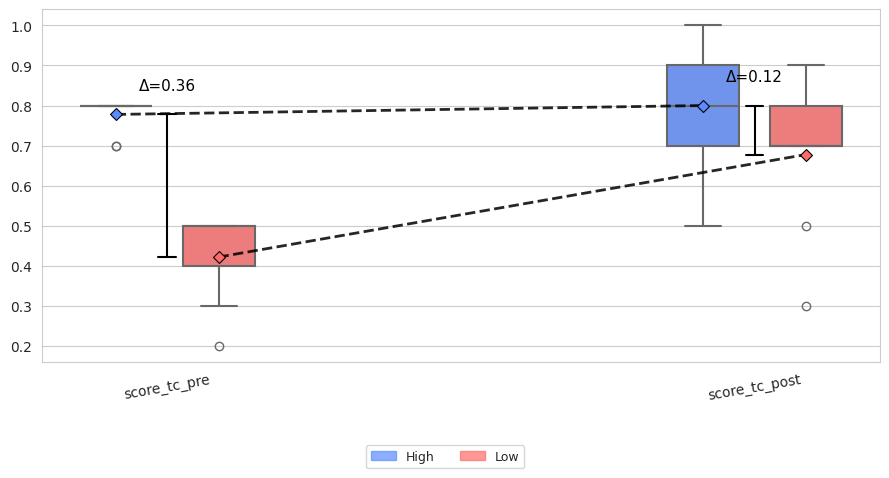

EXPBA


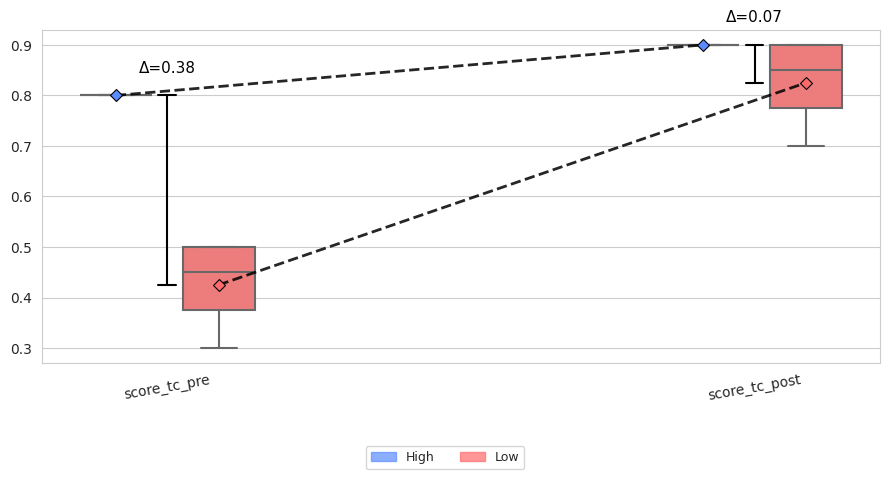

In [295]:
variable = "experimental_type_freq_quality"

for g in df_cat_group_exp[variable].unique().to_list():
    print(g.upper())
    plot_quant_comparison(
        figsize=(9, 4),
        df=df_cat_group_exp.filter(
            pl.col(variable)==g
        ),
        comparisons=[
            ["score_tc_pre", "score_tc_post"]
        ],
        group_by=f"{col}_cat_new_group",
        showfliers=True,
        title=None,
        labelbottom=True,
        xlabel_rotation=10,
        bbox_to_anchor=(0.5, -0.2),
        show_mean_lines=True,
        save_path=os.path.join(knowledge_path, f'mathew_{g}.pdf')
    )

In [296]:
# ---- Preparación ----
df = (forms_interactions_df.to_pandas()
      if hasattr(forms_interactions_df, 'to_pandas')
      else forms_interactions_df.copy())

OUTCOME   = 'score_tc_post'
COVARIATE = 'score_tc_pre'

d = df.dropna(subset=[OUTCOME, COVARIATE, 'group', 'school']).copy()
d['group_binary'] = (d['group'] == 'experimental').astype(int)
pre_mean = d[COVARIATE].mean()
d['pre_c'] = d[COVARIATE] - pre_mean

# Misma categorización que la figura: cortes fijos, franja central excluida
d['prior_cat'] = np.where(d[COVARIATE] <= 0.5, 'Low',
                   np.where(d[COVARIATE] >= 0.7, 'High', None))

print("--- Cobertura de la categorización de la figura ---")
print(f"Low  (<= 0.5): {(d['prior_cat'] == 'Low').sum()}")
print(f"High (>= 0.7): {(d['prior_cat'] == 'High').sum()}")
print(f"Excluidos (0.5 < pre < 0.7): {d['prior_cat'].isna().sum()} "
      f"de {len(d)} ({d['prior_cat'].isna().mean():.1%})\n")

# ================== DESCRIPTIVOS: brechas por estrato ==================
def gap_table(data, label):
    sub = data.dropna(subset=['prior_cat'])
    if sub['prior_cat'].nunique() < 2:
        print(f"{label:<14} datos insuficientes")
        return None
    g = sub.groupby('prior_cat')[[COVARIATE, OUTCOME]].mean()
    n = sub.groupby('prior_cat').size()
    gap_pre  = g.loc['High', COVARIATE] - g.loc['Low', COVARIATE]
    gap_post = g.loc['High', OUTCOME]   - g.loc['Low', OUTCOME]
    print(f"{label:<14} n(High/Low) = {n.get('High',0):>2}/{n.get('Low',0):<2} | "
          f"High {g.loc['High',COVARIATE]:.3f}->{g.loc['High',OUTCOME]:.3f} | "
          f"Low {g.loc['Low',COVARIATE]:.3f}->{g.loc['Low',OUTCOME]:.3f} | "
          f"gap {gap_pre:.3f}->{gap_post:.3f} ({1-gap_post/gap_pre:.1%} reduction)")
    return dict(label=label, n_high=n.get('High', 0), n_low=n.get('Low', 0),
                gap_pre=gap_pre, gap_post=gap_post)

print("--- Brechas alto/bajo rendimiento previo (cortes fijos de la figura) ---")
rows = [gap_table(d[d['group'] == 'control'], 'Control'),
        gap_table(d[d['group'] == 'experimental'], 'Experimental')]
for lvl in ['ExpA', 'ExpB', 'ExpNotUsed']:
    if lvl in d['group_segmented_quality'].astype(str).unique():
        rows.append(gap_table(d[d['group_segmented_quality'].astype(str) == lvl], lvl))
for lvl in ['ExpAA', 'ExpBA', 'ExpAB', 'ExpBB']:
    if lvl in d['group_segmented_freq_quality'].astype(str).unique():
        rows.append(gap_table(
            d[d['group_segmented_freq_quality'].astype(str) == lvl], lvl))

# ================== REGRESIÓN A LA MEDIA ==================
# Bajo ausencia total de efecto diferencial, la brecha se reduce por el simple
# hecho de haber seleccionado los extremos del pre. La magnitud esperada de esa
# reducción es 1 - r, con r la correlación pre-post dentro de cada condición.
print("\n--- Cierre esperado por regresión a la media ---")
for lbl, sub in [('Control', d[d['group'] == 'control']),
                 ('Experimental', d[d['group'] == 'experimental'])]:
    r = sub[COVARIATE].corr(sub[OUTCOME])
    print(f"{lbl:<14} r(pre, post) = {r:.3f} -> reducción esperada de la brecha "
          f"por regresión a la media ~ {1-r:.1%}")

# ================== MODELO: moderación por rendimiento previo ==================
# La pregunta "¿se cierra más la brecha en el grupo experimental?" es, formalmente,
# si el efecto de la condición varía con el nivel previo: el término de interacción.
print("\n--- M3: interacción condición x conocimiento previo (escala continua) ---")
m2 = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", d,
                 groups=d['school'], re_formula="1").fit(reml=True)
m3 = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", d,
                 groups=d['school'], re_formula="1").fit(reml=True)

t = 'group_binary:pre_c'
ci = m3.conf_int().loc[t]
print(f"beta3 = {m3.params[t]:+.4f} (SE {m3.bse[t]:.4f}, p {m3.pvalues[t]:.4f}, "
      f"95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}])")

m2ml = smf.mixedlm(f"{OUTCOME} ~ group_binary + pre_c", d, groups=d['school'],
                   re_formula="1").fit(reml=False)
m3ml = smf.mixedlm(f"{OUTCOME} ~ group_binary * pre_c", d, groups=d['school'],
                   re_formula="1").fit(reml=False)
lr = 2 * (m3ml.llf - m2ml.llf)
print(f"LR test M2 vs M3: chi2 = {lr:.4f}, df = 1, p = {stats.chi2.sf(lr,1):.4f}")

# Pendiente pre->post dentro de cada condición: si el experimental "compensa",
# su pendiente debería ser MENOR (menos dependencia del punto de partida).
print("\n--- Pendiente del pre dentro de cada condición ---")
for lbl, sub in [('Control', d[d['group'] == 'control']),
                 ('Experimental', d[d['group'] == 'experimental'])]:
    m = smf.mixedlm(f"{OUTCOME} ~ pre_c", sub, groups=sub['school'],
                    re_formula="1").fit(reml=True)
    ci_s = m.conf_int().loc['pre_c']
    print(f"{lbl:<14} beta_pre = {m.params['pre_c']:+.4f} "
          f"(SE {m.bse['pre_c']:.4f}, p {m.pvalues['pre_c']:.4f}, "
          f"95% CI [{ci_s[0]:+.4f}, {ci_s[1]:+.4f}])")

# Misma interacción dentro del grupo experimental, por perfil de uso
print("\n--- Interacción perfil x conocimiento previo (solo experimental) ---")
de = d[d['group'] == 'experimental'].copy()
de['prof'] = de['group_segmented_quality'].astype(str)
try:
    mi = smf.mixedlm(f"{OUTCOME} ~ C(prof, Treatment(reference='ExpA')) * pre_c",
                     de, groups=de['school'], re_formula="1").fit(reml=True)
    for name in mi.params.index:
        if ':pre_c' in name and name.startswith('C('):
            lvl = name.split('[T.')[-1].split(']')[0]
            ci_i = mi.conf_int().loc[name]
            print(f"{lvl:<12} beta = {mi.params[name]:+.4f} "
                  f"(p {mi.pvalues[name]:.4f}, 95% CI [{ci_i[0]:+.4f}, {ci_i[1]:+.4f}])")
except Exception as exc:
    print(f"no estimable: {type(exc).__name__}: {exc}")

--- Cobertura de la categorización de la figura ---
Low  (<= 0.5): 63
High (>= 0.7): 67
Excluidos (0.5 < pre < 0.7): 53 de 183 (29.0%)

--- Brechas alto/bajo rendimiento previo (cortes fijos de la figura) ---
Control        n(High/Low) = 35/35 | High 0.771->0.846 | Low 0.397->0.729 | gap 0.374->0.117 (68.7% reduction)
Experimental   n(High/Low) = 32/28 | High 0.769->0.797 | Low 0.411->0.714 | gap 0.358->0.083 (76.9% reduction)
ExpA           n(High/Low) = 10/6  | High 0.780->0.840 | Low 0.433->0.800 | gap 0.347->0.040 (88.5% reduction)
ExpB           n(High/Low) = 13/13 | High 0.754->0.762 | Low 0.392->0.700 | gap 0.362->0.062 (83.0% reduction)
ExpNotUsed     n(High/Low) =  9/9  | High 0.778->0.800 | Low 0.422->0.678 | gap 0.356->0.122 (65.6% reduction)
ExpAA          n(High/Low) =  8/2  | High 0.775->0.825 | Low 0.450->0.750 | gap 0.325->0.075 (76.9% reduction)
ExpBA          n(High/Low) =  2/4  | High 0.800->0.900 | Low 0.425->0.825 | gap 0.375->0.075 (80.0% reduction)
ExpAB         

/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

beta3 = -0.0976 (SE 0.1358, p 0.4725, 95% CI [-0.3638, +0.1687])


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/fabio/fabio_scielzo

LR test M2 vs M3: chi2 = 0.5284, df = 1, p = 0.4673

--- Pendiente del pre dentro de cada condición ---
Control        beta_pre = +0.2444 (SE 0.0918, p 0.0078, 95% CI [+0.0645, +0.4243])
Experimental   beta_pre = +0.1951 (SE 0.1078, p 0.0703, 95% CI [-0.0162, +0.4064])

--- Interacción perfil x conocimiento previo (solo experimental) ---
ExpB         beta = +0.1367 (p 0.6088, 95% CI [-0.3867, +0.6600])
ExpNotUsed   beta = +0.3278 (p 0.2517, 95% CI [-0.2327, +0.8884])


/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/fabio/fabio_scielzo_ortiz/va-educational-impact/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

#### Hake Gain

In [180]:
no_efecto_techo_df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)).filter(
    pl.col("score_tc_pre") < 0.8	
)

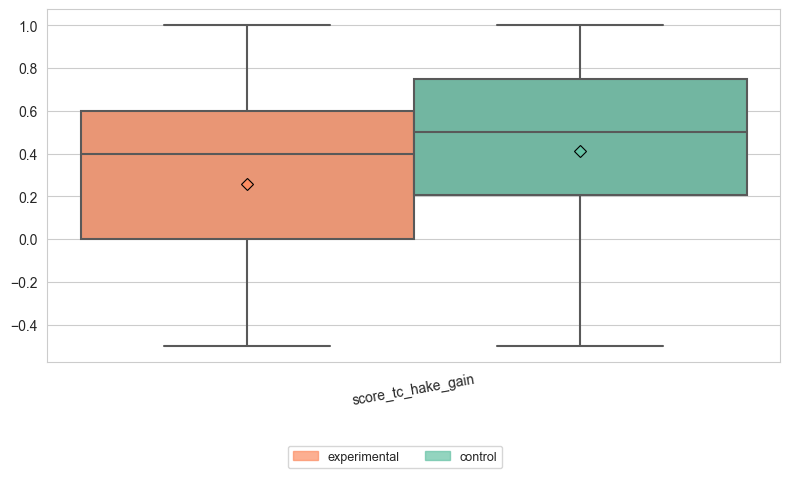

In [181]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
         ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    order=['experimental', 'control'],
    figsize=(8,4),
    save_path=os.path.join(knowledge_path, 'hake_gain_comparison.pdf')
)

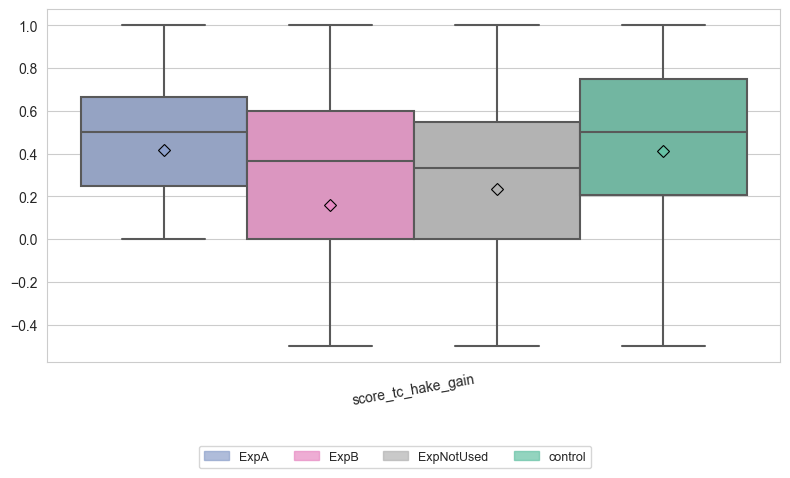

In [182]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    figsize=(8,4),
    save_path=os.path.join(knowledge_path, 'hake_gain_quality.pdf')
)

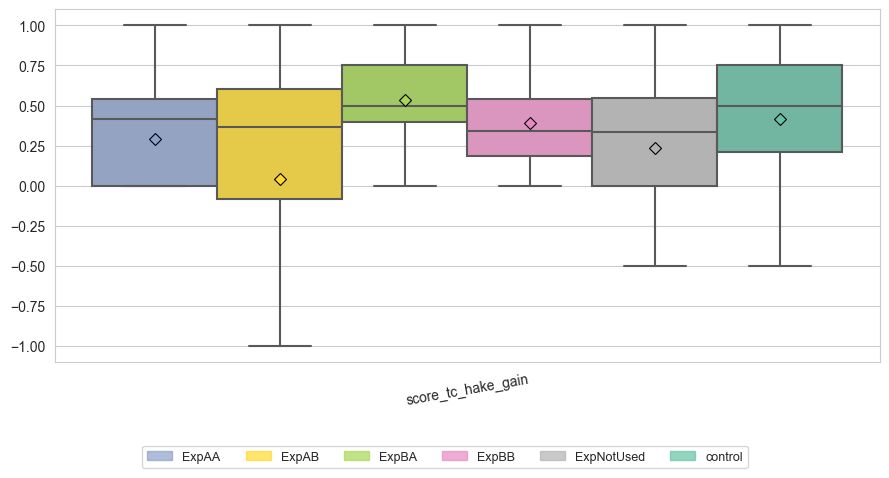

In [183]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_freq_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    save_path=os.path.join(knowledge_path, 'hake_gain_frq_quality.pdf')
)

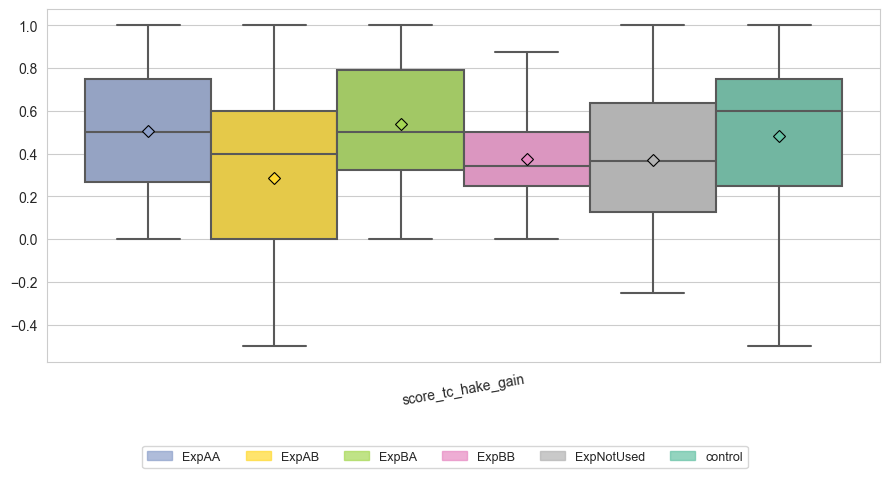

In [184]:
plot_quant_comparison(
    figsize = (9,4),
    df = no_efecto_techo_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_freq_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    save_path=os.path.join(knowledge_path, 'hake_gain_frq_quality_no_ceiling_effect.pdf')
)

#### Correlation plots

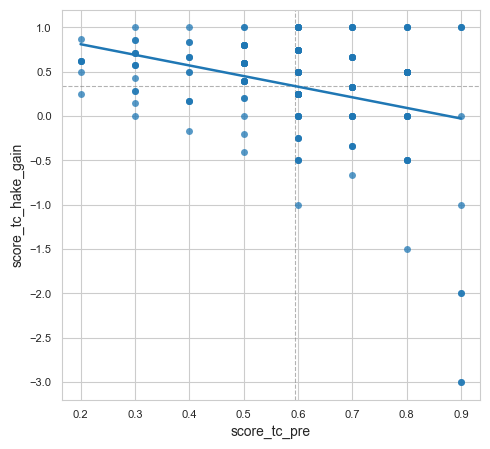

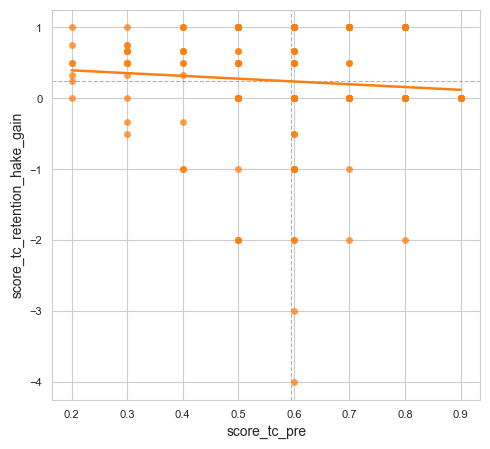

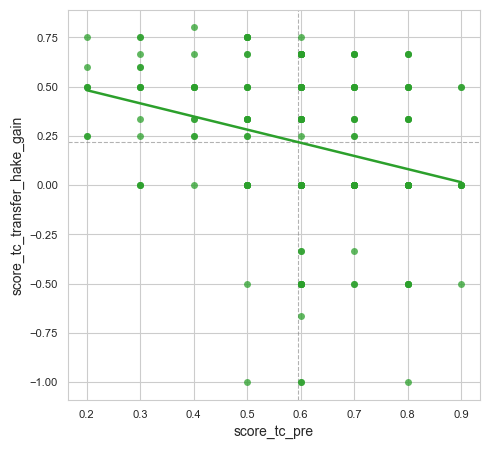

In [185]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_transfer.pdf')
)

In [186]:
cols_2 = [
    "score_tc_hake_gain",
    "score_tc_retention_hake_gain",
    "score_tc_transfer_hake_gain"
]

for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_tc_pre",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(-0.3303549661488646), 'pearson_p': np.float64(4.942284329654823e-06)}, 'spearman': {'spearman_r': np.float64(-0.23970104513400112), 'spearman_p': np.float64(0.001082433961517392)}}
{'pearson': {'pearson_r': np.float64(-0.08282993232857472), 'pearson_p': np.float64(0.264961257616635)}, 'spearman': {'spearman_r': np.float64(-0.12400637083543542), 'spearman_p': np.float64(0.0944269202777078)}}
{'pearson': {'pearson_r': np.float64(-0.2859764563651373), 'pearson_p': np.float64(8.695113509220556e-05)}, 'spearman': {'spearman_r': np.float64(-0.2982355668792863), 'spearman_p': np.float64(4.1222469433788804e-05)}}


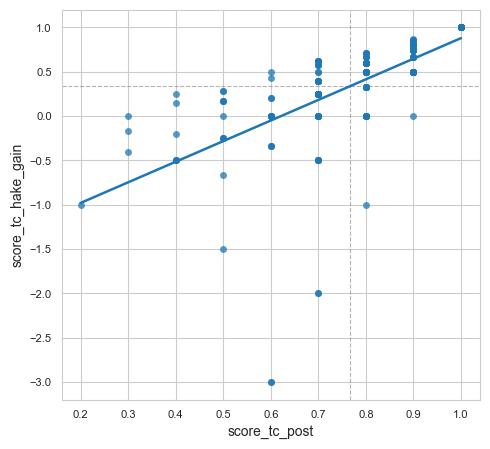

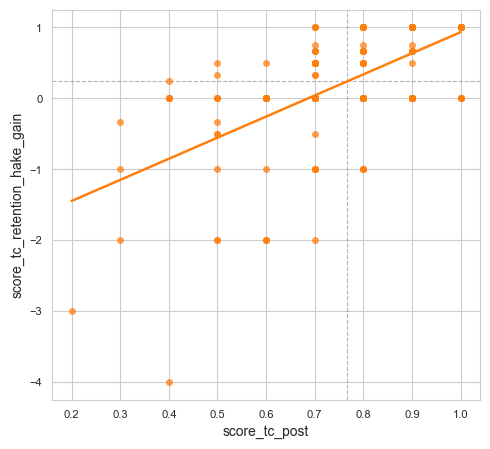

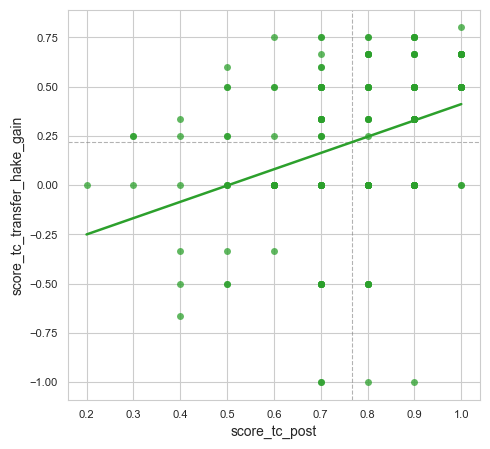

In [187]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_hake_gain"), 
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_transfer.pdf')
)

In [188]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_tc_post",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.6320305667479138), 'pearson_p': np.float64(8.4360202573197855e-22)}, 'spearman': {'spearman_r': np.float64(0.8383864054743115), 'spearman_p': np.float64(1.4022925270836523e-49)}}
{'pearson': {'pearson_r': np.float64(0.618584411328048), 'pearson_p': np.float64(1.048724120601181e-20)}, 'spearman': {'spearman_r': np.float64(0.6310623205350168), 'spearman_p': np.float64(1.0156539885392935e-21)}}
{'pearson': {'pearson_r': np.float64(0.34913251103443593), 'pearson_p': np.float64(1.273048710365881e-06)}, 'spearman': {'spearman_r': np.float64(0.41220153870660214), 'spearman_p': np.float64(6.718948596500451e-09)}}


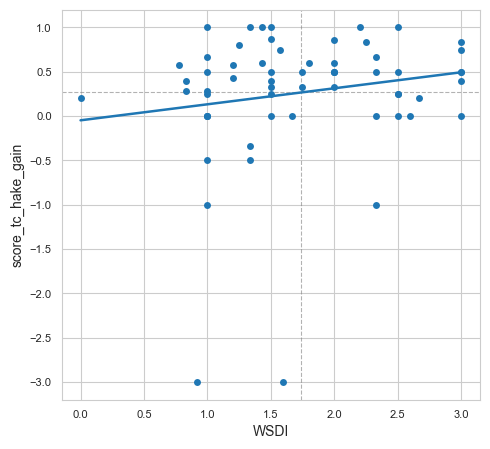

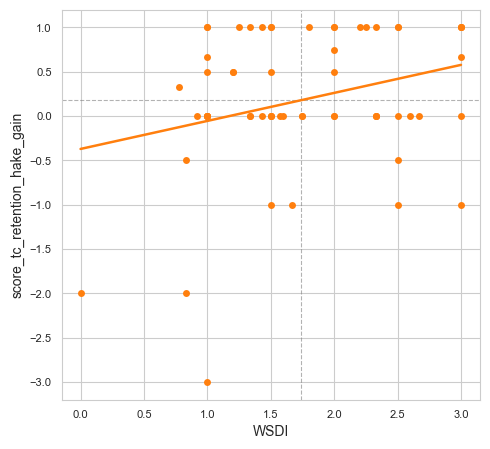

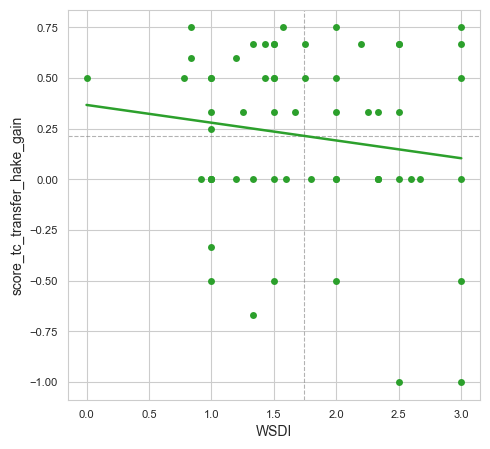

In [189]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_transfer.pdf')
)

In [190]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "WSDI",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.17076180264597193), 'pearson_p': np.float64(0.18824483776505563)}, 'spearman': {'spearman_r': np.float64(0.1419290349279892), 'spearman_p': np.float64(0.27522736142406073)}}
{'pearson': {'pearson_r': np.float64(0.2726747702999409), 'pearson_p': np.float64(0.03349756279237057)}, 'spearman': {'spearman_r': np.float64(0.1829850520048646), 'spearman_p': np.float64(0.15808473703519776)}}
{'pearson': {'pearson_r': np.float64(-0.14389869333487126), 'pearson_p': np.float64(0.2685516183757617)}, 'spearman': {'spearman_r': np.float64(-0.06528380666380786), 'spearman_p': np.float64(0.6171678474816557)}}


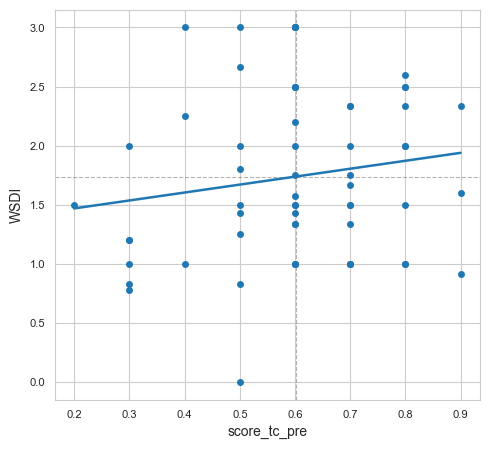

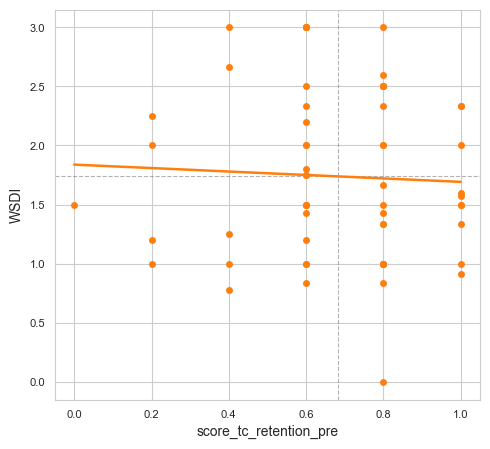

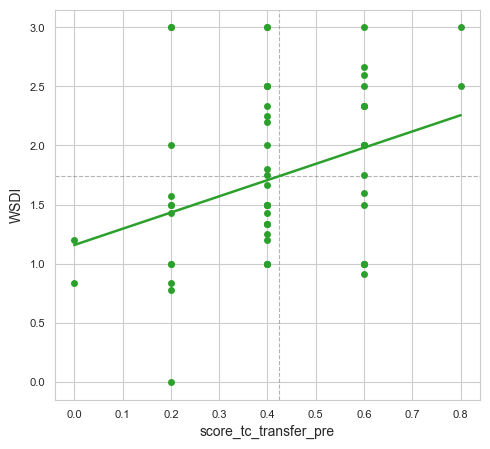

In [191]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_retention_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_transfer_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_transfer.pdf')
)

In [192]:
cols_1 = [
    "score_tc_pre",
    "score_tc_retention_pre",
    "score_tc_transfer_pre"
]

for col in cols_1:
    results = compute_correlations(
        forms_interactions_df,
        col1 = col,
        col2 = "WSDI",
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.15747280276523376), 'pearson_p': np.float64(0.22549817544982417)}, 'spearman': {'spearman_r': np.float64(0.15141953889330345), 'spearman_p': np.float64(0.24406359935805919)}}
{'pearson': {'pearson_r': np.float64(-0.04783642776665884), 'pearson_p': np.float64(0.7142942830378224)}, 'spearman': {'spearman_r': np.float64(-0.05871664901124009), 'spearman_p': np.float64(0.6530763636824426)}}
{'pearson': {'pearson_r': np.float64(0.3406172649132084), 'pearson_p': np.float64(0.007228980174480924)}, 'spearman': {'spearman_r': np.float64(0.32227234132433946), 'spearman_p': np.float64(0.011311383289604382)}}


In [193]:
# plot_cat_comparison_faceted(
#     forms_interactions_df,
#     comparisons=[
#         ["WSDI_cat_v2"],
#     ],
#     outer_group_by= "WSDI_cat_v2",
#     outer_order=['Deep', 'Superficial', 'Cheating', 'Out of context', 'Not Used'],
#     order=["Low", "Medium", "High"],
#     group_by="score_tc_cat_pre",   #          
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     #save_path=os.path.join(knowledge_path, 'improvement_nota_pre.pdf')
# )

#### Mejora

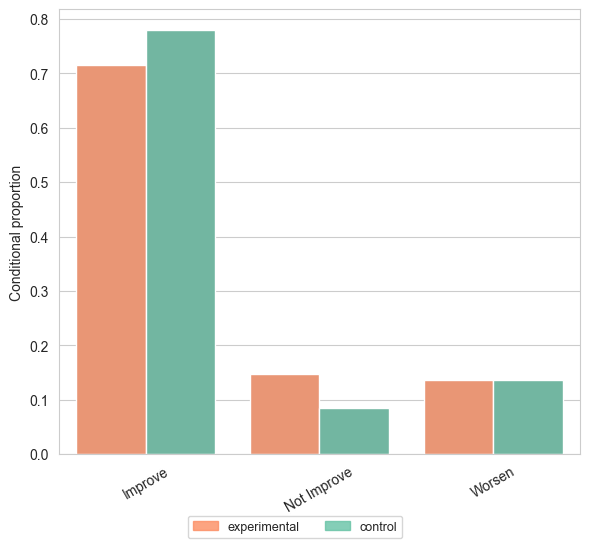

In [194]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group',
    order=['Improve', 'Not Improve', 'Worsen'],
    hue_order=['experimental', 'control'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_comparison.pdf')
)

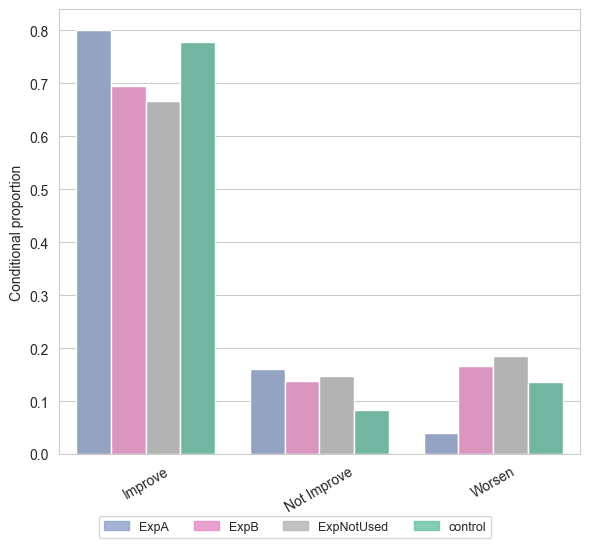

In [195]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_quality.pdf')
)


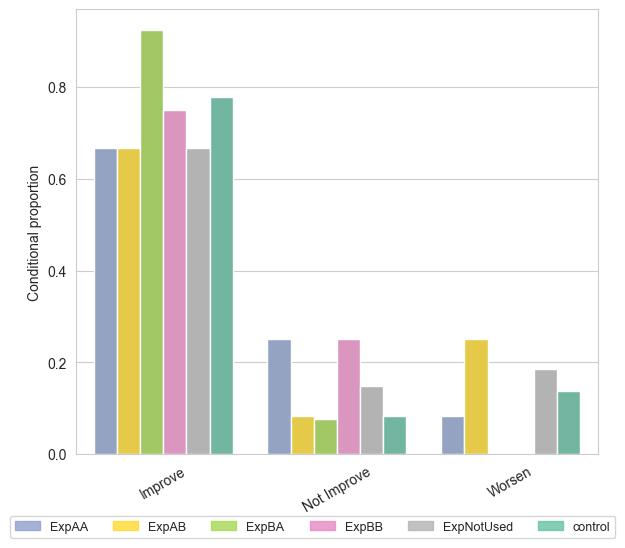

In [196]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_freq_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_frq_quality.pdf')
)

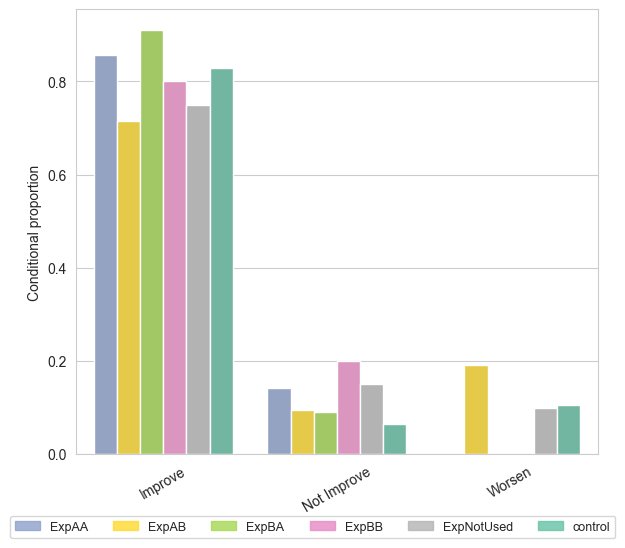

In [197]:
plot_cat_comparison(
    df=no_efecto_techo_df, 
    comparisons=[
        ['improvement_hake_gain'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_freq_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'improvement_frq_quality_ceiling_effect.pdf')
)


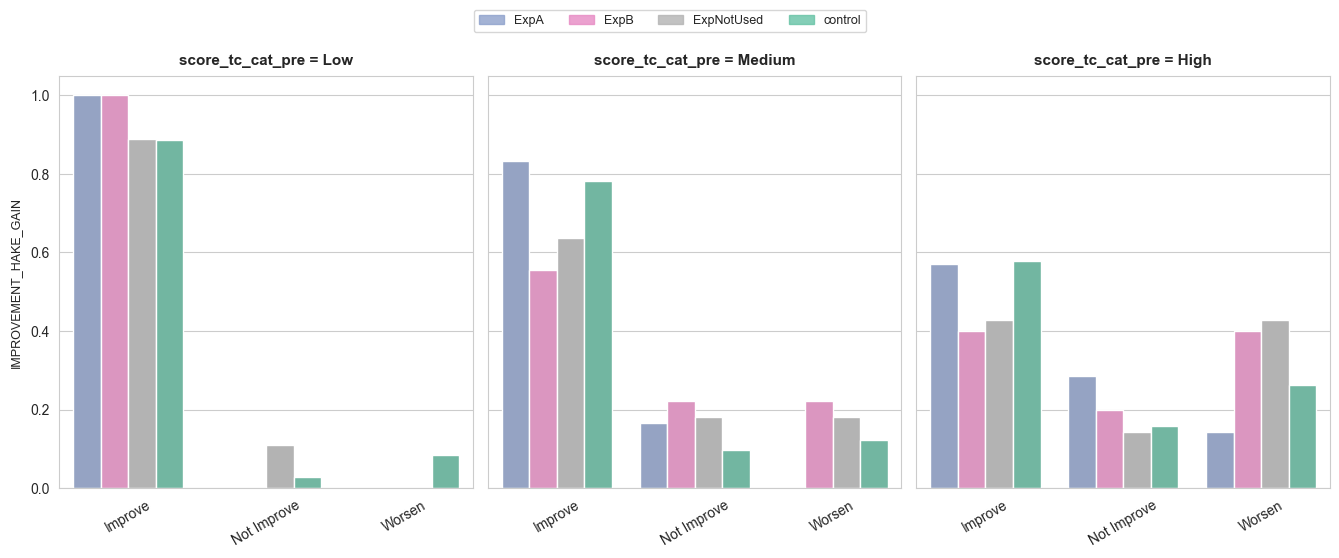

In [198]:
plot_cat_comparison_faceted(
    forms_interactions_df,
    comparisons=[
        ["improvement_hake_gain"],
    ],
    outer_group_by= "score_tc_cat_pre",
    outer_order=["Low", "Medium", "High"],
    order=['Improve', 'Not Improve', 'Worsen'],
    group_by="group_segmented_quality",            
    palette="Set2",
    bbox_to_anchor=(0.5, 1),
    sharey="all",
    save_path=os.path.join(knowledge_path, 'improvement_nota_pre.pdf')
)

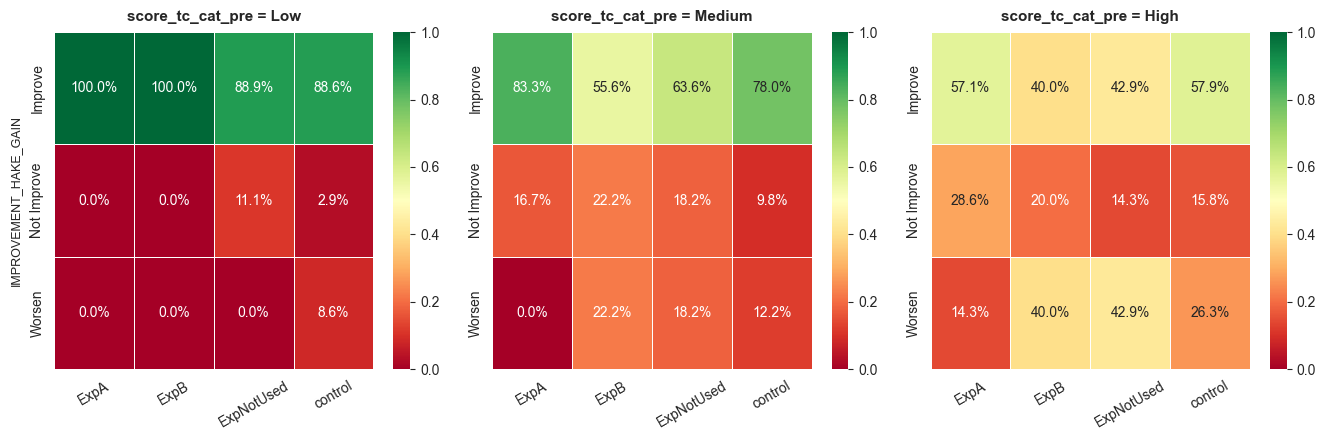

In [199]:
plot_cat_comparison_faceted_heatmap(
    forms_interactions_df,
    comparisons=[
        ["improvement_hake_gain"],
    ],
    outer_group_by="score_tc_cat_pre",
    outer_order=["Low", "Medium", "High"],
    order=['Improve', 'Not Improve', 'Worsen'],
    group_by="group_segmented_quality",
    cmap="RdYlGn",
    show_counts=True,
    save_path=os.path.join(knowledge_path, 'improvement_nota_pre_heatmap.pdf'),
)

#### Evaluation Chat

In [200]:
# plot_cat_comparison(
#     df=forms_interactions_df.filter(
#         pl.col('group') == 'experimental',
#         pl.col('evaluation_pass').is_not_null()
#     ), 
#     comparisons=[
#         ['evaluation_pass'],
#     ], 
#     title=None,
#     hue_order=["Not Used", "Out of context", "Cheating", "Superficial", "Deep"], 
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='WSDI_cat_v2',
#     subplots_title=False,
#     save_path=os.path.join(knowledge_path, 'evaluation_pass_by_depth.pdf')
# )

In [201]:
# cheating_not_cheating = forms_interactions_df.with_columns(
#     pl.when(pl.col("WSDI_cat_v2") == "Cheating")
#     .then(pl.lit("Cheating"))
#     .otherwise(pl.lit("No Cheating"))
#     .alias("do_cheat")
# ).filter(
#     pl.col("evaluation_pass").is_not_null()
# ).with_columns(
#     pl.col("evaluation_pass").cast(pl.String),
# )

# plot_cat_comparison_faceted(
#     cheating_not_cheating,
#     comparisons=[
#         ["improvement_hake_gain_v2"],
#     ],
#     outer_group_by="do_cheat",
#     group_by="evaluation_pass",        
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     order=['Improve', 'Not Improve', 'Worsen'],
#     save_path=os.path.join(knowledge_path, 'evaluation_pass_mejora.pdf')
# )

### Self-efficiency

In [202]:
self_efficacy_path = os.path.join(plots_path, '5_2', '5_2_3')
os.makedirs(self_efficacy_path, exist_ok=True)

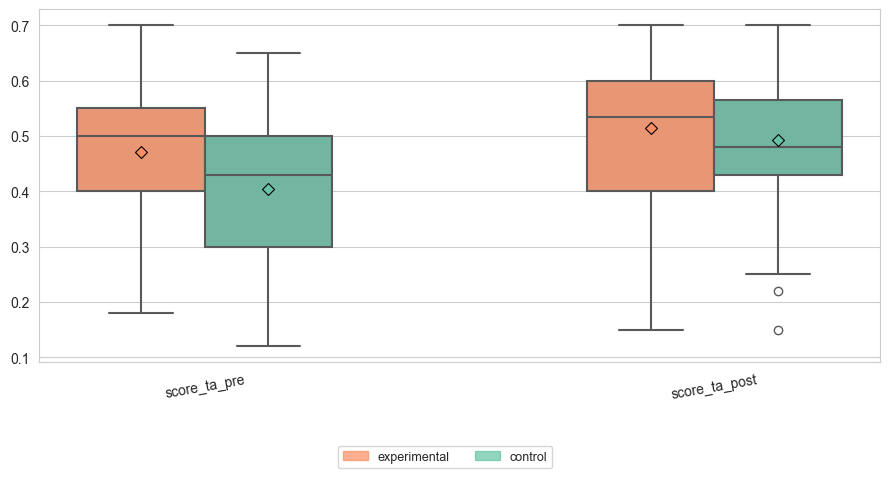

In [203]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_ta_pre', 'score_ta_post']
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(self_efficacy_path, 'self_confidence_comparison.pdf')
)

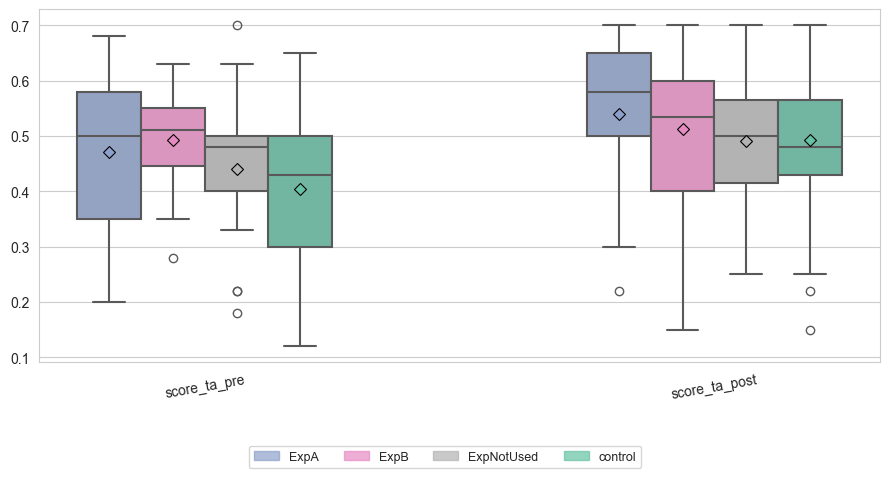

In [204]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_ta_pre', 'score_ta_post']
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(self_efficacy_path, 'self_confidence_quality.pdf')
)

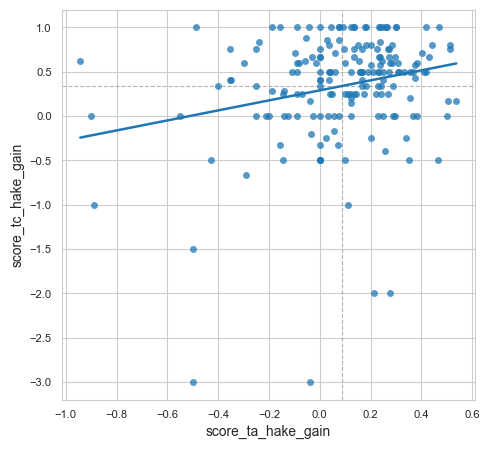

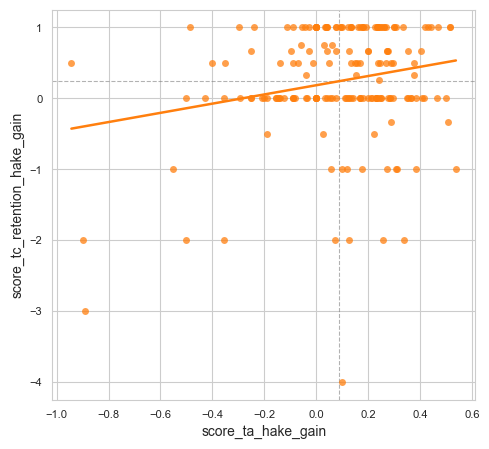

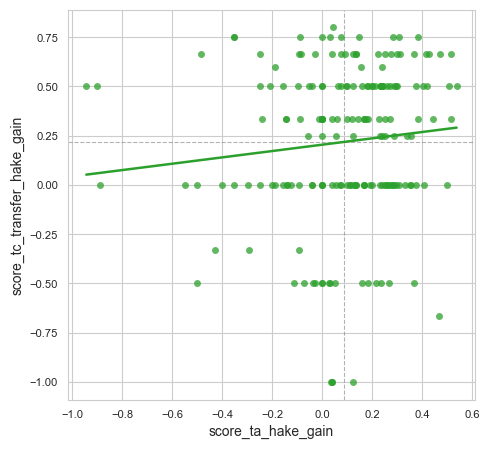

In [205]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_transfer.pdf')
)

In [206]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_ta_hake_gain",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.2284550564311273), 'pearson_p': np.float64(0.001867411376682705)}, 'spearman': {'spearman_r': np.float64(0.1673013771194766), 'spearman_p': np.float64(0.023593694929186913)}}
{'pearson': {'pearson_r': np.float64(0.20074337649088067), 'pearson_p': np.float64(0.0064342070098755075)}, 'spearman': {'spearman_r': np.float64(0.07214503644880091), 'spearman_p': np.float64(0.3317784424920426)}}
{'pearson': {'pearson_r': np.float64(0.10114490124855495), 'pearson_p': np.float64(0.1730768141218981)}, 'spearman': {'spearman_r': np.float64(0.13068580925748), 'spearman_p': np.float64(0.07784295100640083)}}


### Cognitive load

In [207]:
cognitive_load_path = os.path.join(plots_path, '5_2', '5_2_4')
os.makedirs(cognitive_load_path, exist_ok=True)

In [208]:
# plot_cat_comparison(
#     df=forms_interactions_df, 
#     comparisons=[
#         ['score_tcc_rel_cat_post'], ['score_tcc_ext_cat_post'], ['score_tcc_int_cat_post'],
#     ], 
#     title=None,
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='group',
#     order=["Low", "Medium", "High"],
#     hue_order=['experimental', 'control'],
#     save_path=os.path.join(cognitive_load_path, 'tcc_levels.pdf')
# )

In [209]:
# plot_cat_comparison(
#     df=forms_interactions_df, 
#     comparisons=[
#         ['score_tcc_rel_cat_post'], ['score_tcc_ext_cat_post'], ['score_tcc_int_cat_post'],
#     ], 
#     title=None,
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='group_segmented_quality',
#     order=["Low", "Medium", "High"],
#     save_path=os.path.join(cognitive_load_path, 'tcc_levels_quality.pdf')
# )

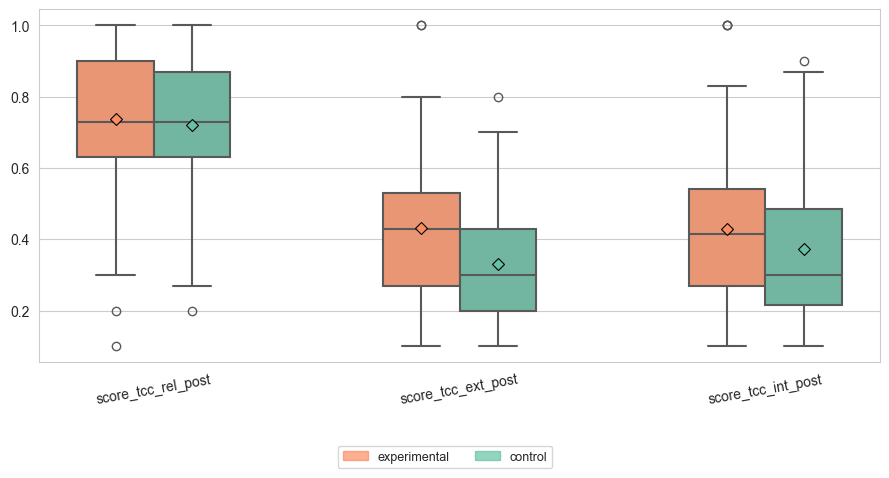

In [210]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_comparison.pdf')
)

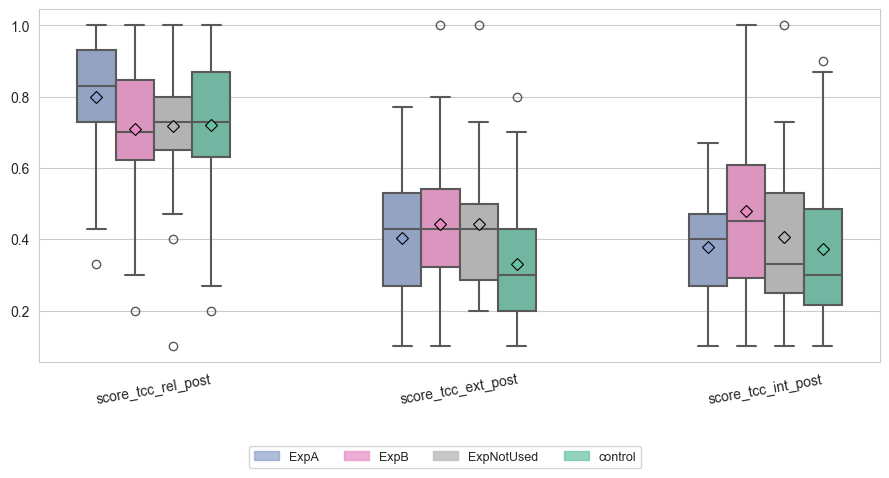

In [211]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_comparison_quality.pdf')
)

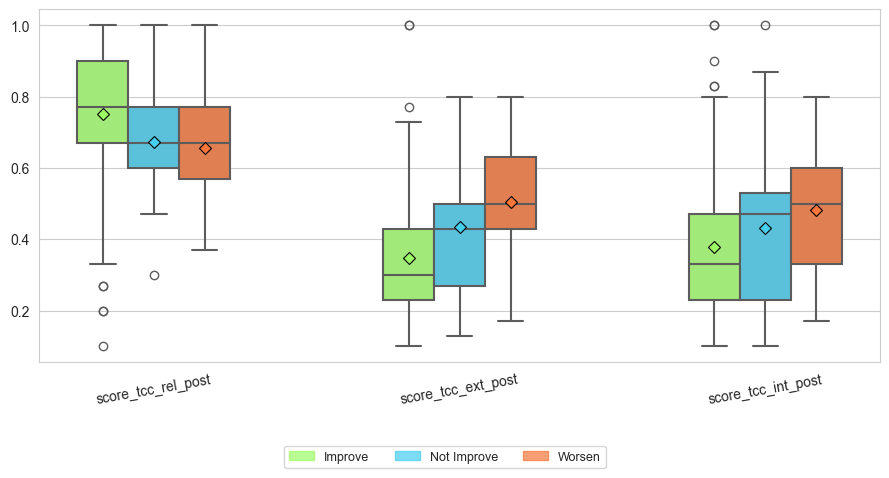

In [212]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='improvement_hake_gain',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_mejora.pdf')
)

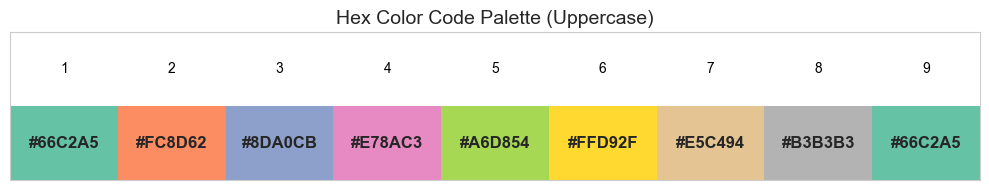

Uppercase hex palette:
['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3', '#A6D854', '#FFD92F', '#E5C494', '#B3B3B3', '#66C2A5']


In [213]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Get a color palette (any desired palette)
palette = sns.color_palette("Set2", 9)  # You can change this to any palette name

# Convert hex codes to uppercase
uppercase_palette = [mcolors.rgb2hex(color).upper() for color in palette]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Display colors
for i, color in enumerate(uppercase_palette):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none'))
    ax.text(i + 0.5, 0.5, color, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(i + 0.5, 1.5, str(i + 1), ha='center', va='center', fontsize=10, color='black')

ax.set_xlim(0, len(uppercase_palette))
ax.set_ylim(0, 2)
ax.set_title('Hex Color Code Palette (Uppercase)', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Print the palette for reference
print("Uppercase hex palette:")
print(uppercase_palette)